In [9]:
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [10]:
PROJECT_DIR = Path.cwd().parent
LABELS_PATH = PROJECT_DIR / "data" / "niftis" / "train_labels_JNDlMjr.csv"
labels = pd.read_csv(LABELS_PATH)
print(labels.head())
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
files_uid = {f.stem.replace(".nii", "") for f in NIFTI_DIR.glob("*.nii.gz")}
labels_uid = set(labels["uid"])
files = sorted(NIFTI_DIR.glob("*.nii.gz"))

        uid  is_pathologic
0  xaji0y6d            0.0
1  pbhsahxt            0.0
2  hv3a3zmf            0.0
3  8mdd4v30            0.0
4  t9nt3w5u            1.0


In [11]:
target_map = labels.set_index("uid")["is_pathologic"].to_dict()

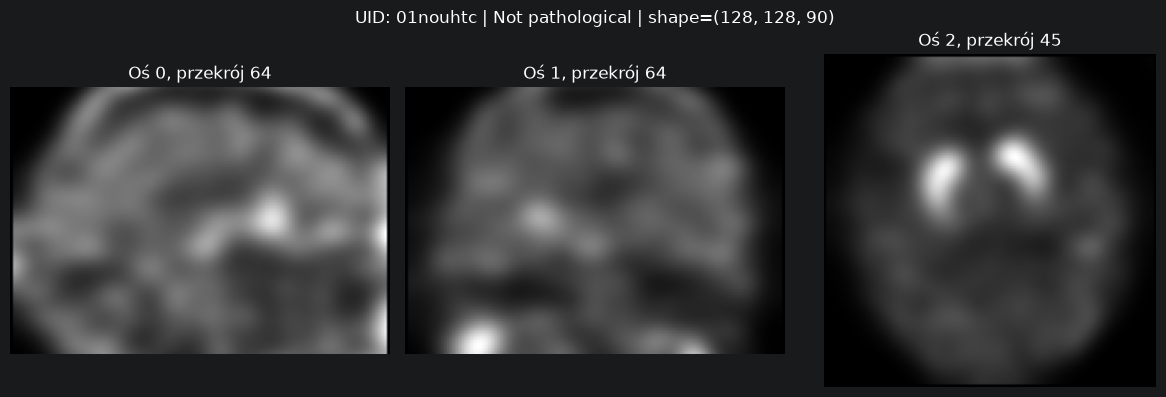

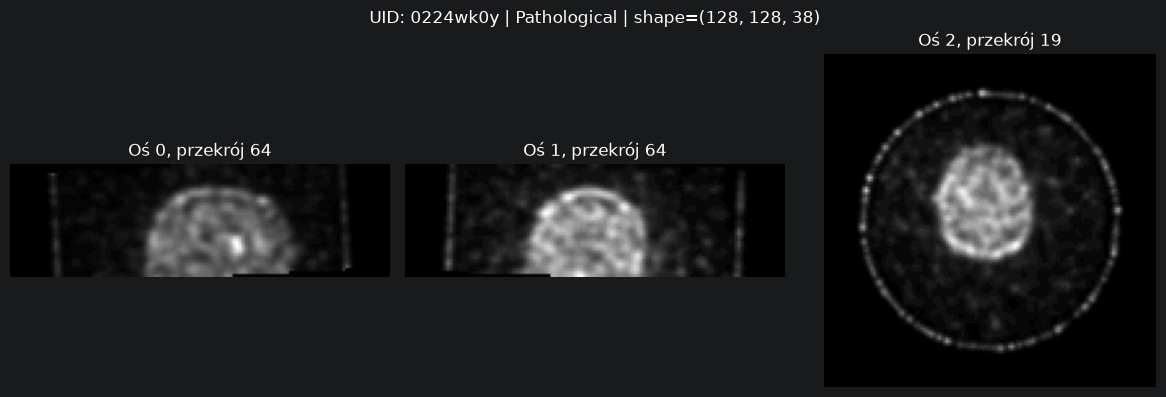

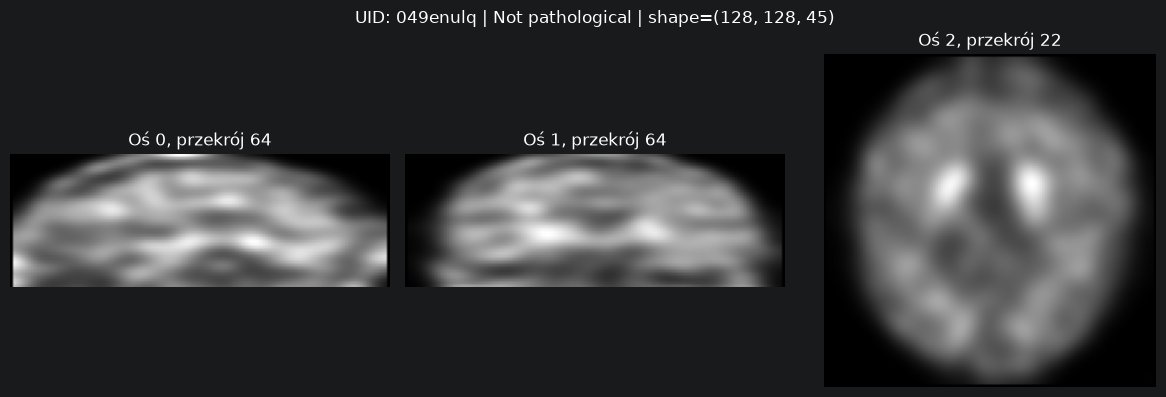

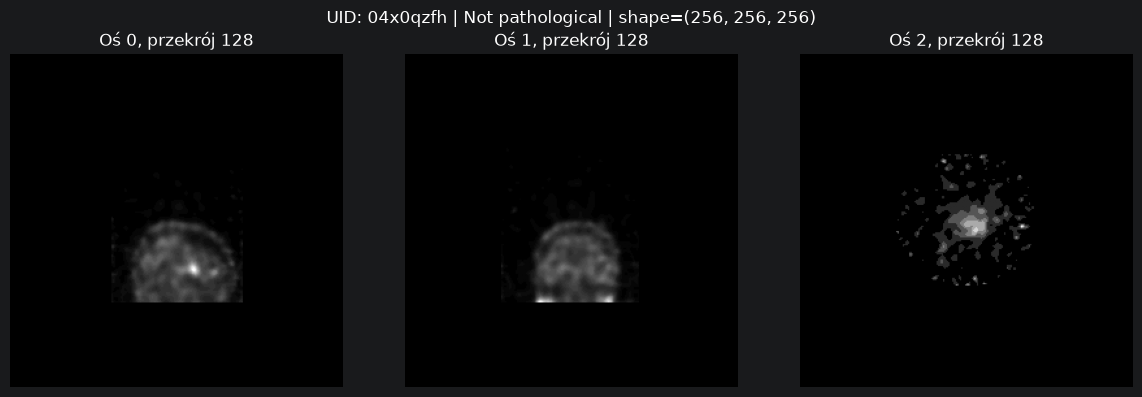

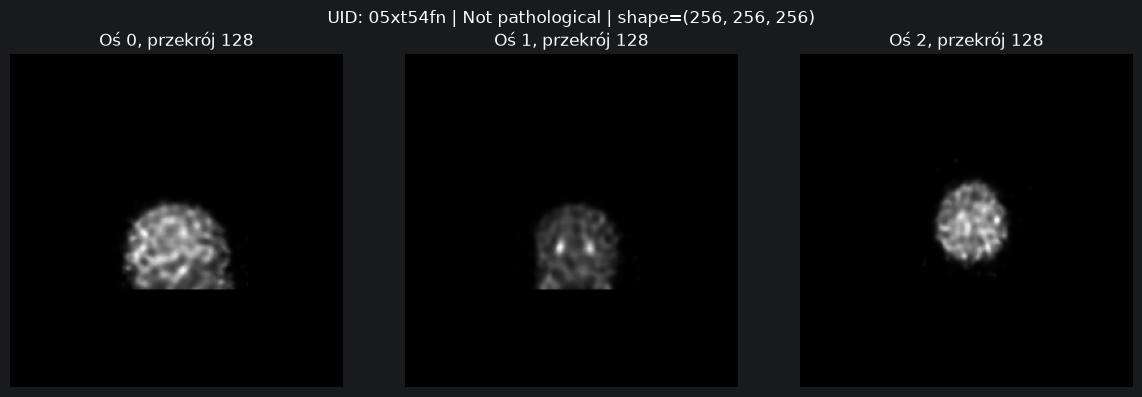

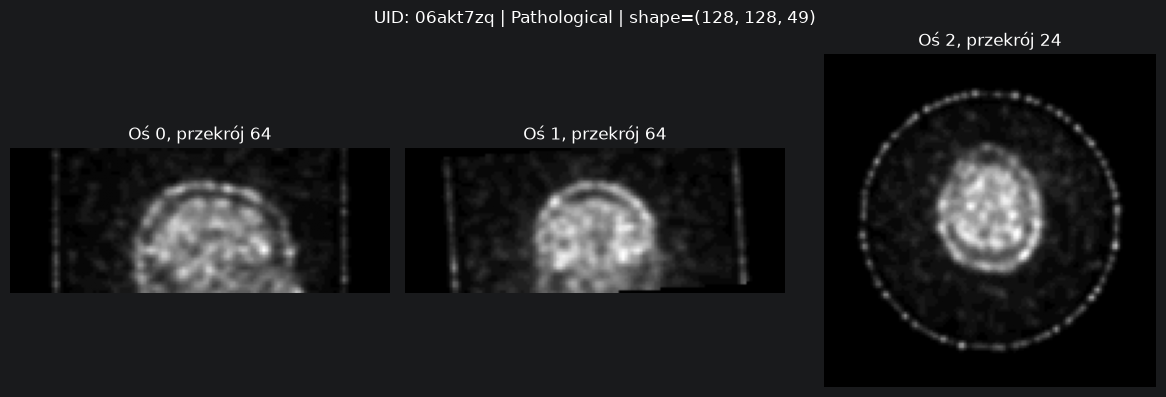

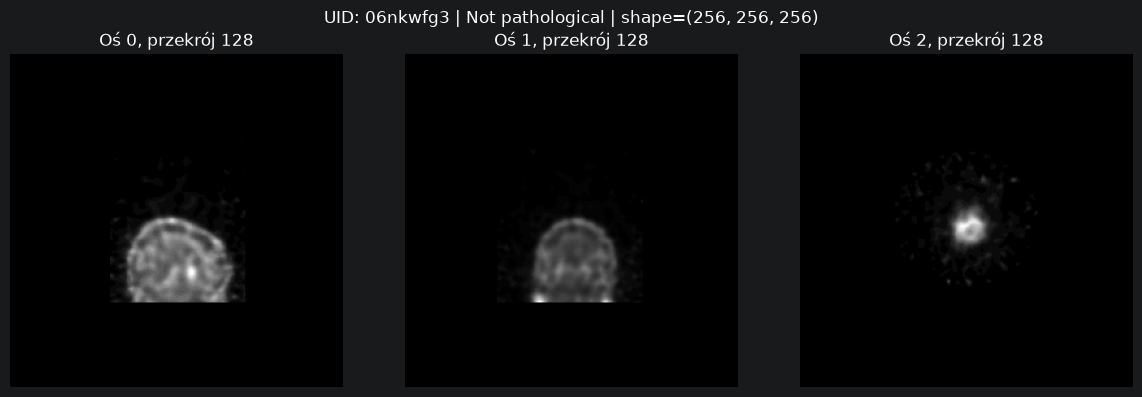

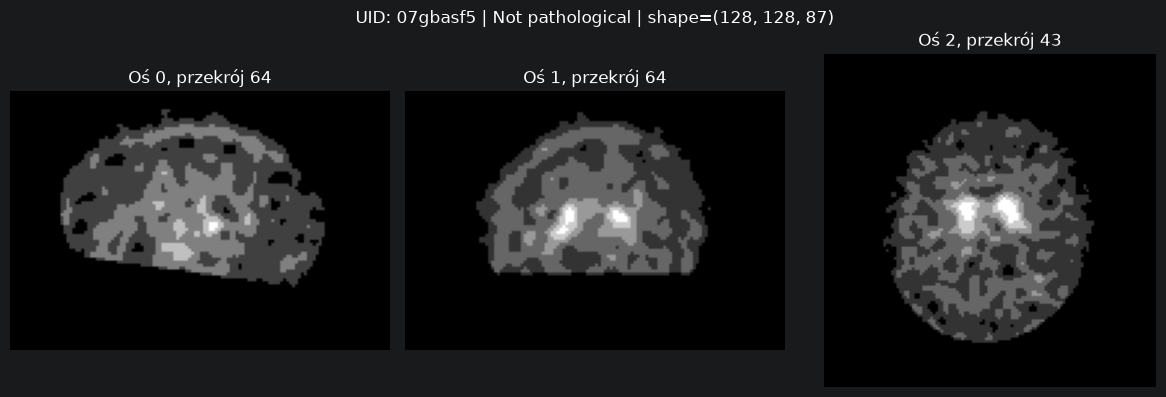

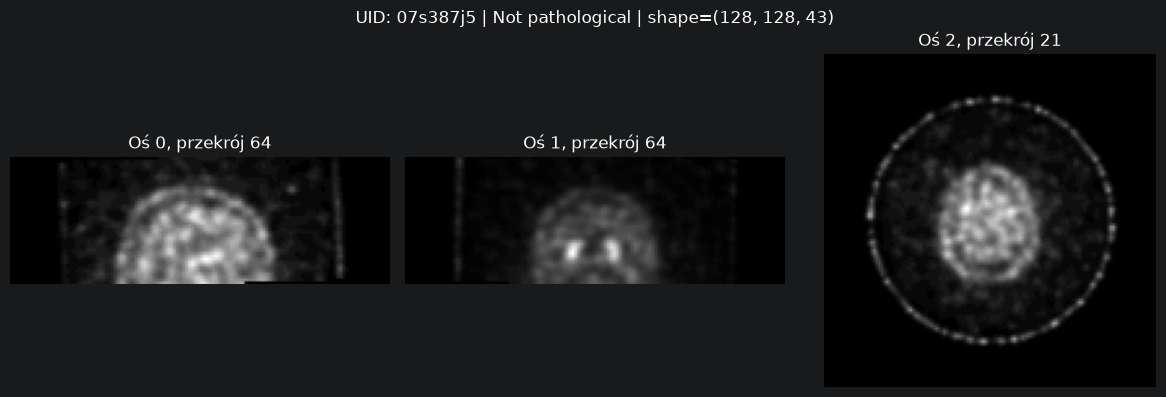

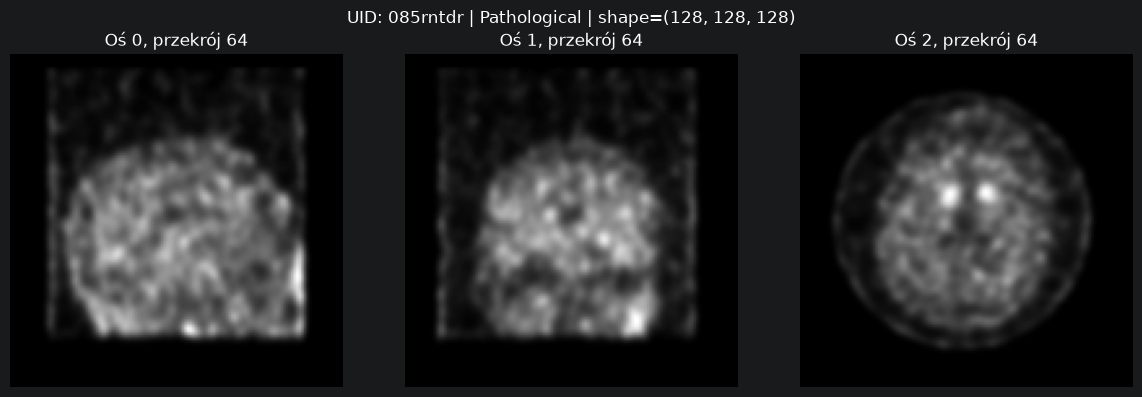

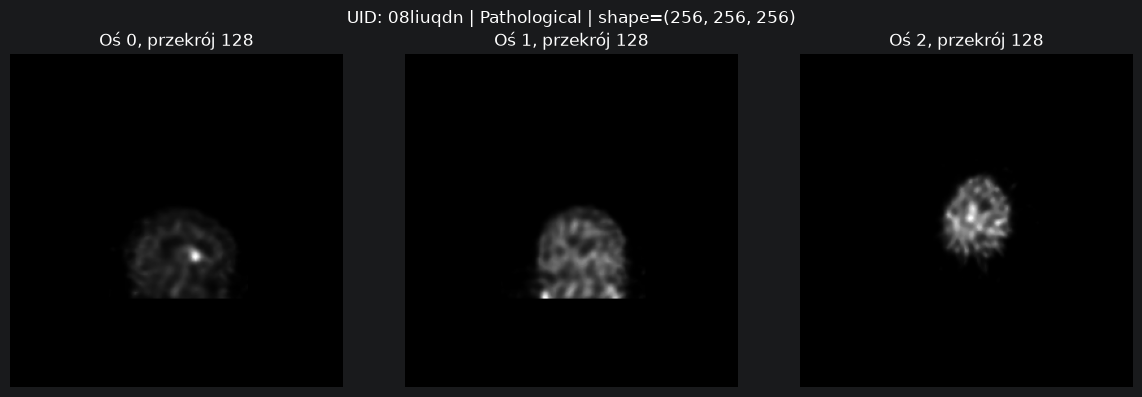

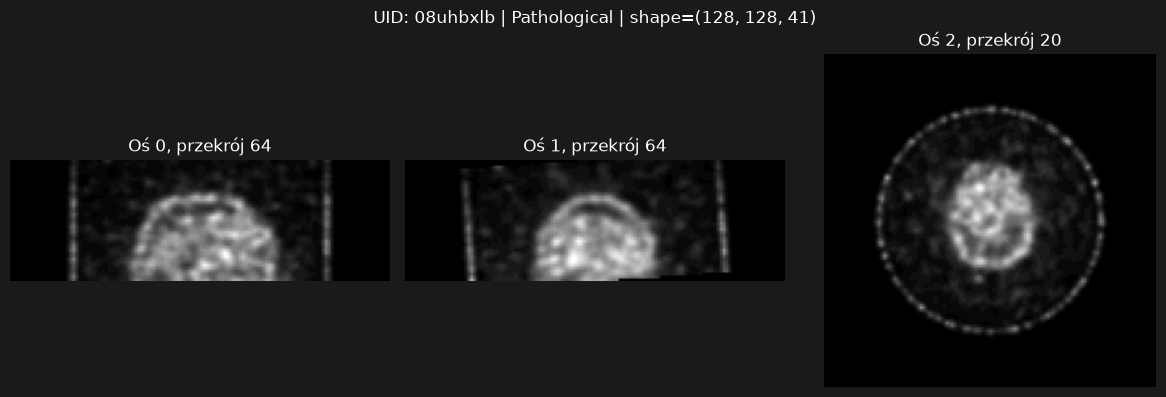

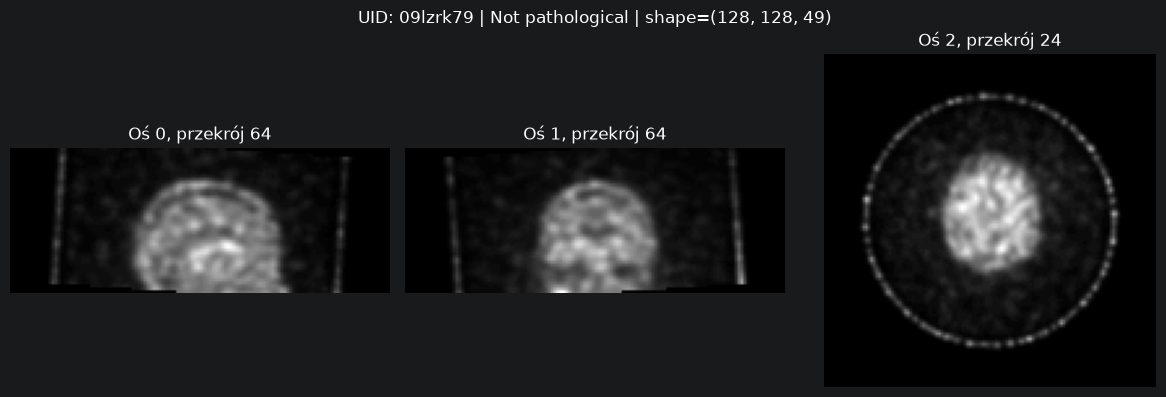

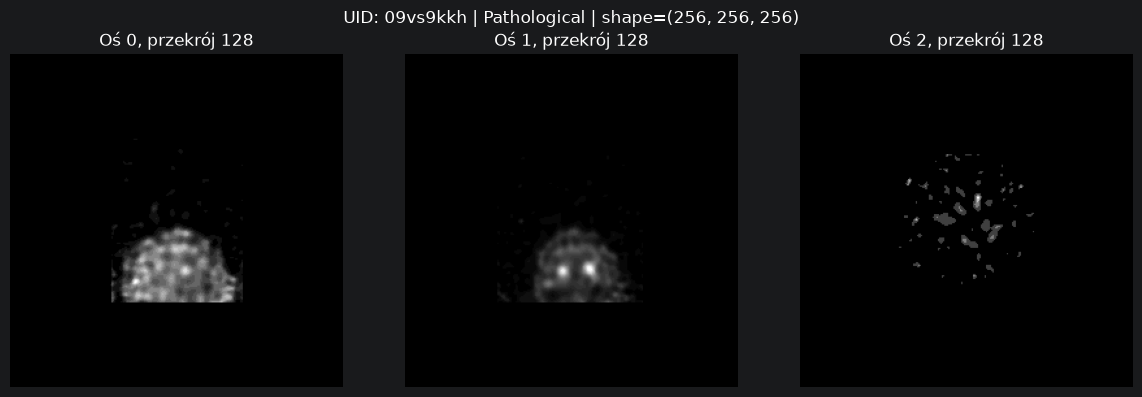

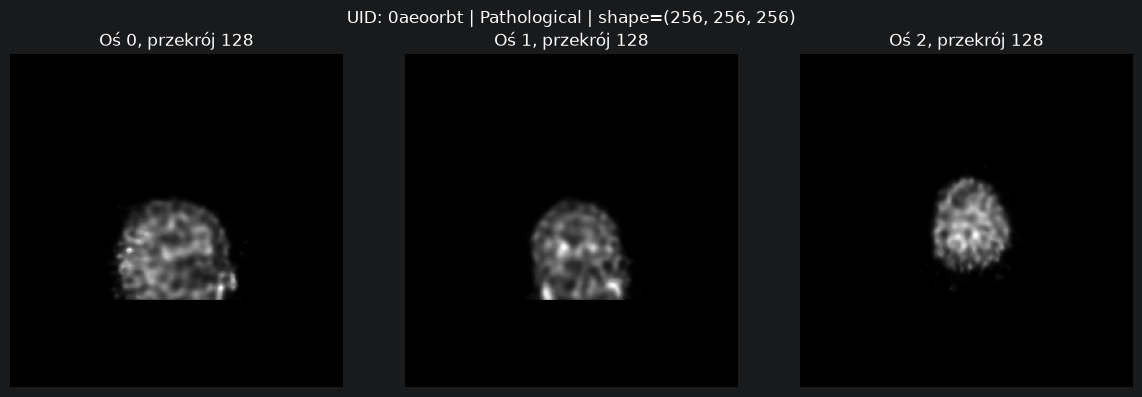

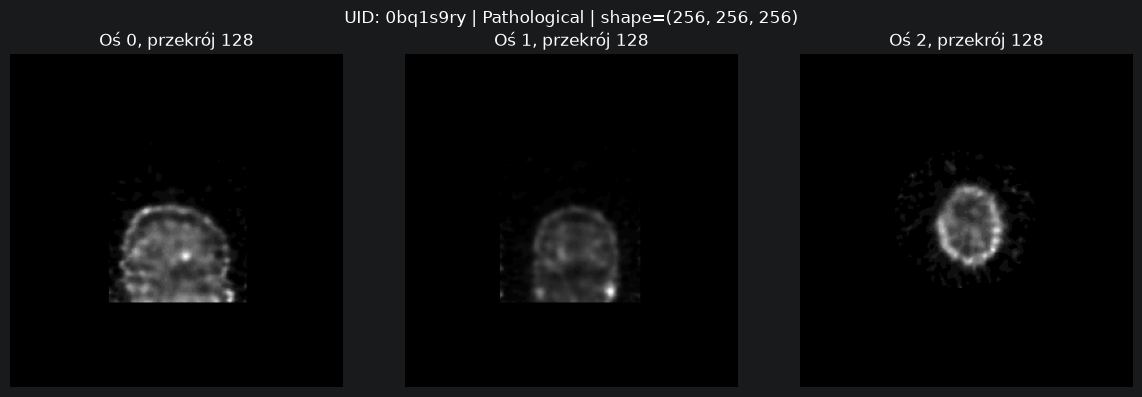

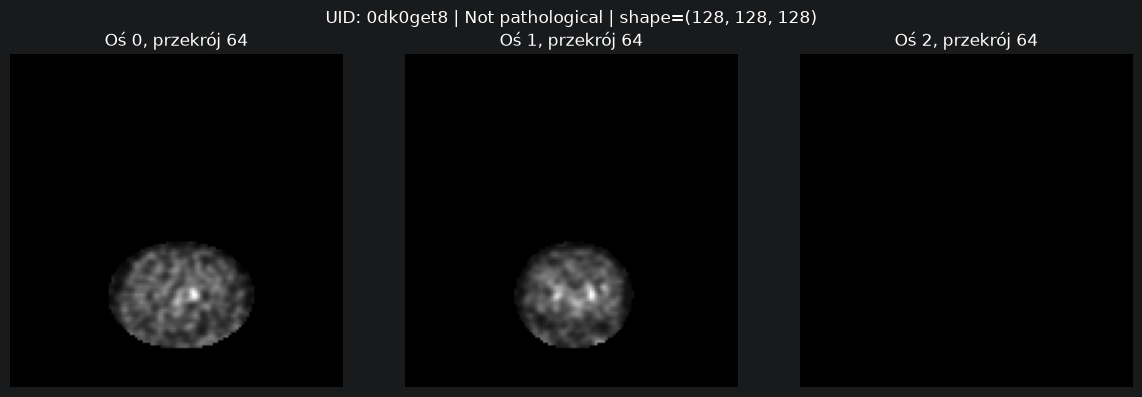

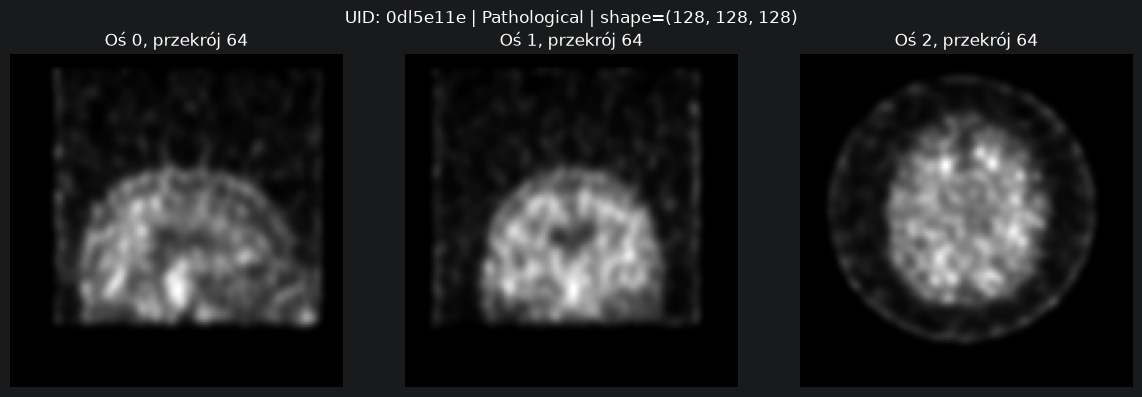

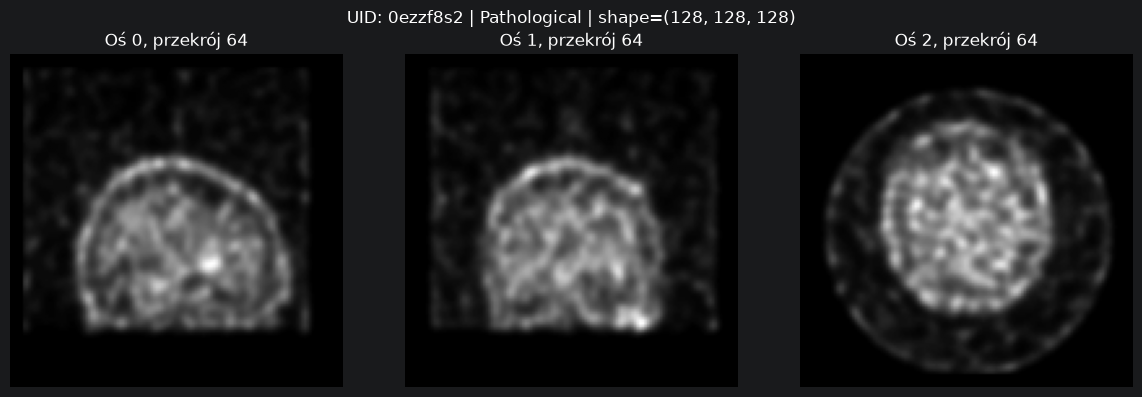

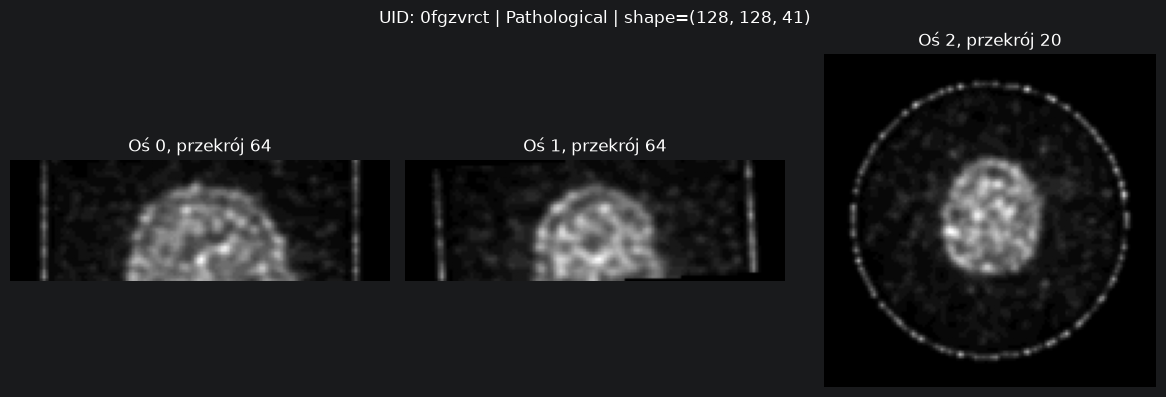

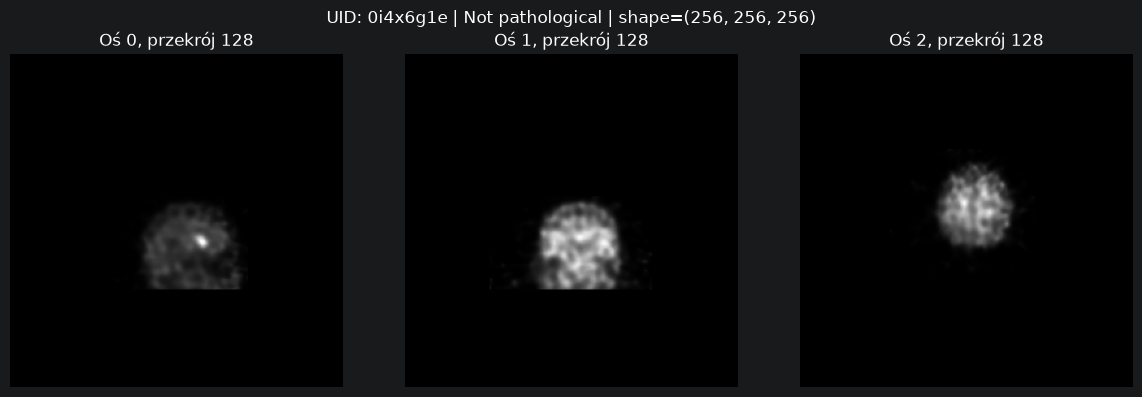

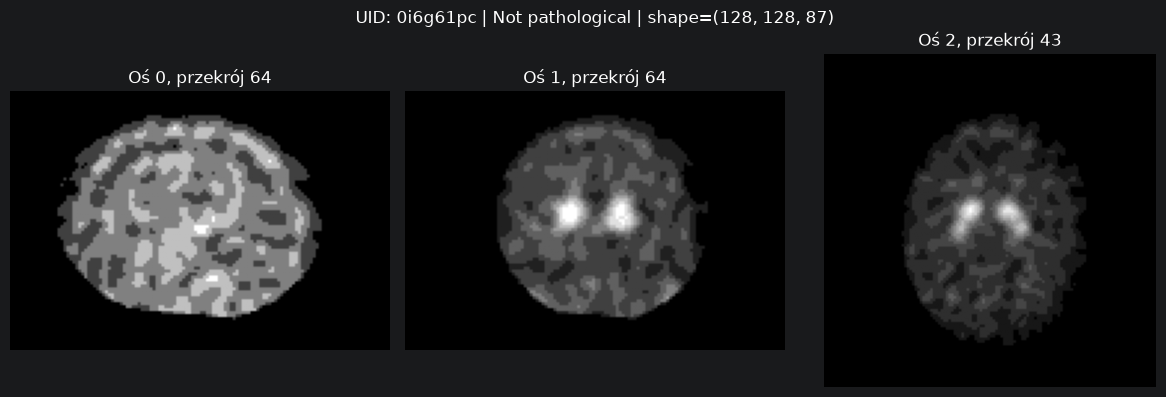

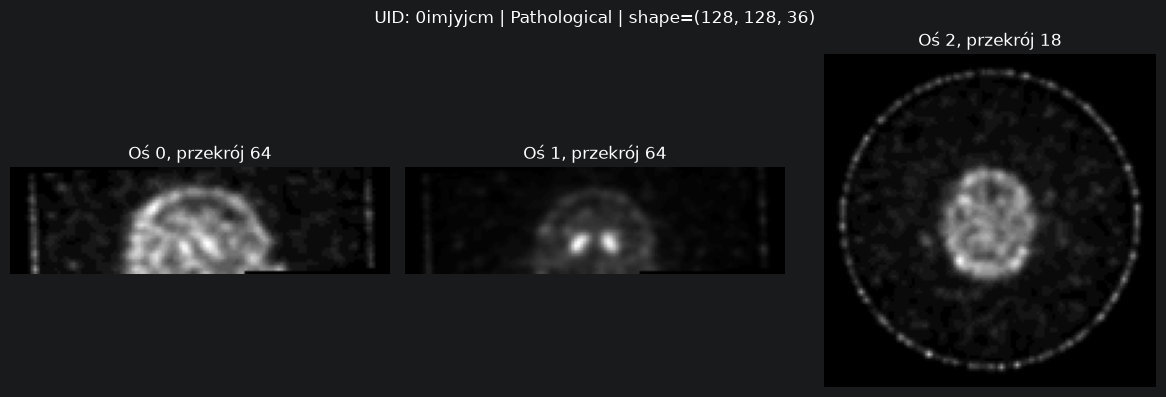

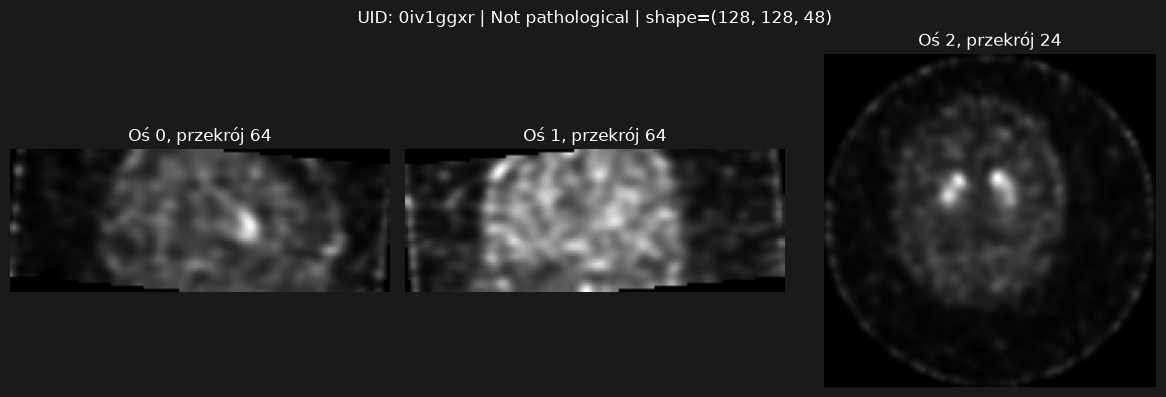

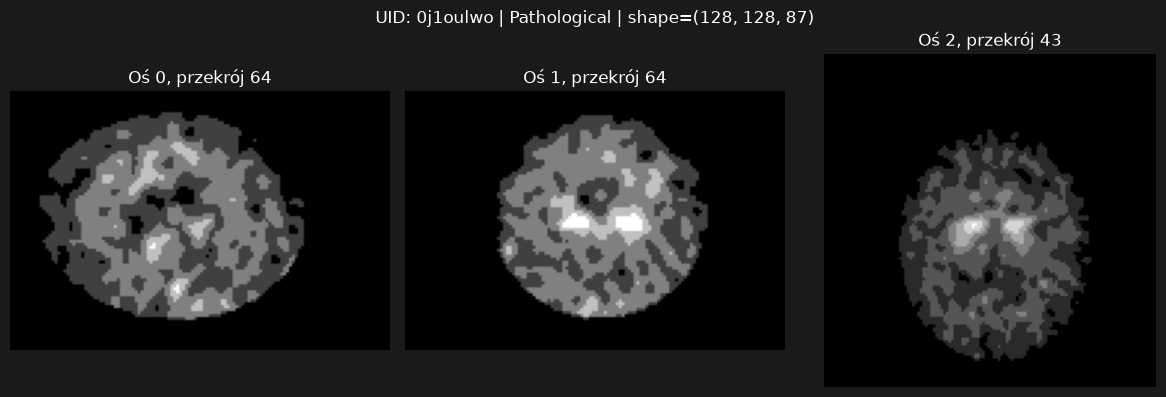

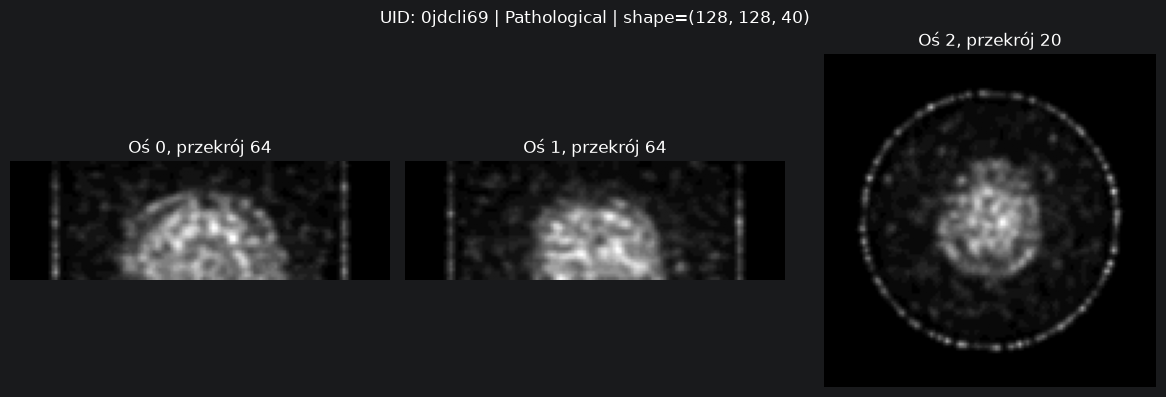

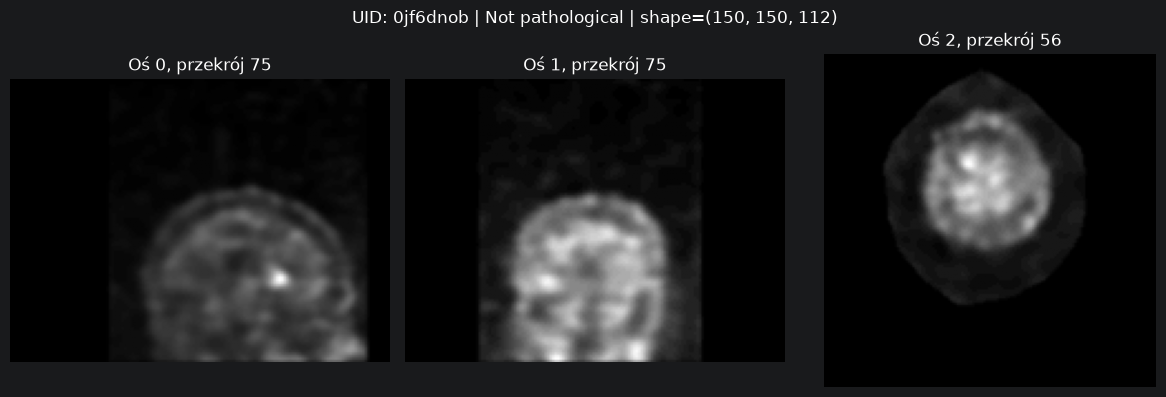

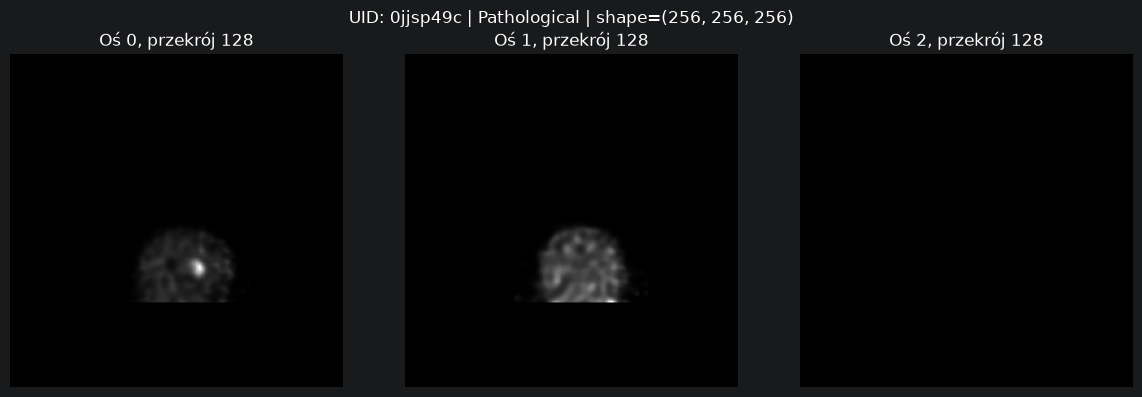

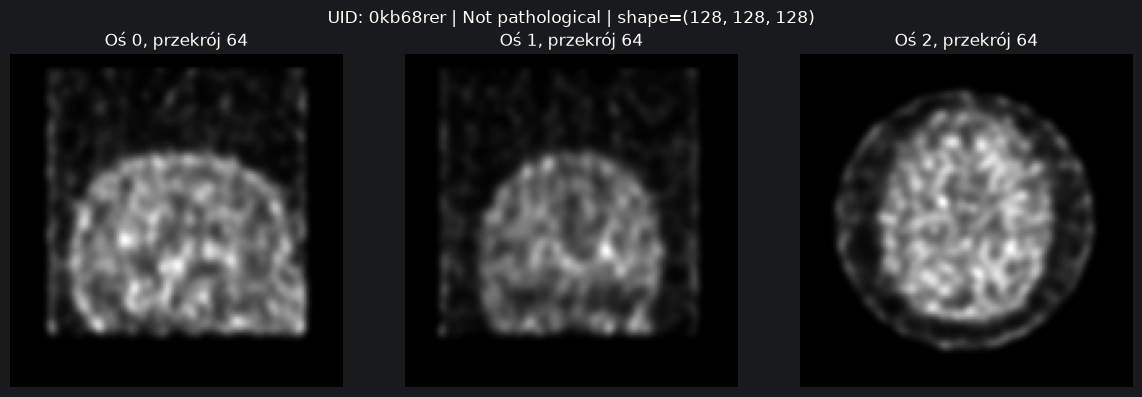

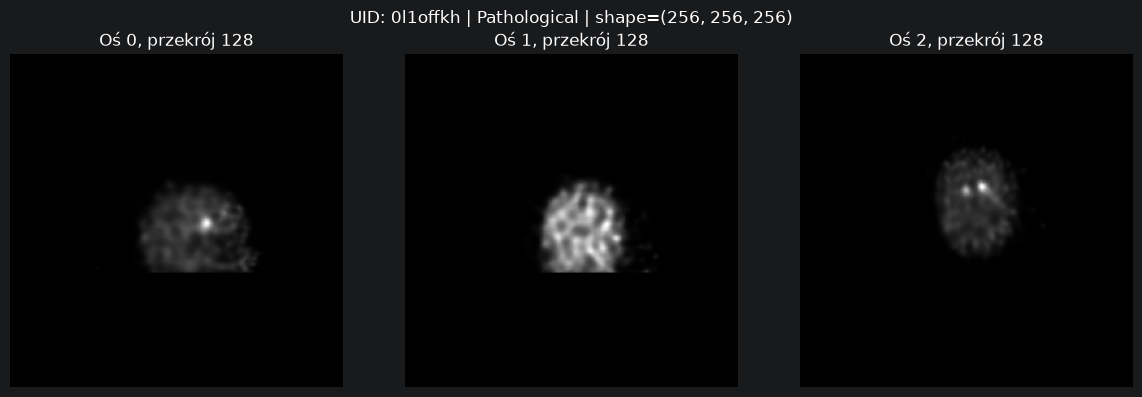

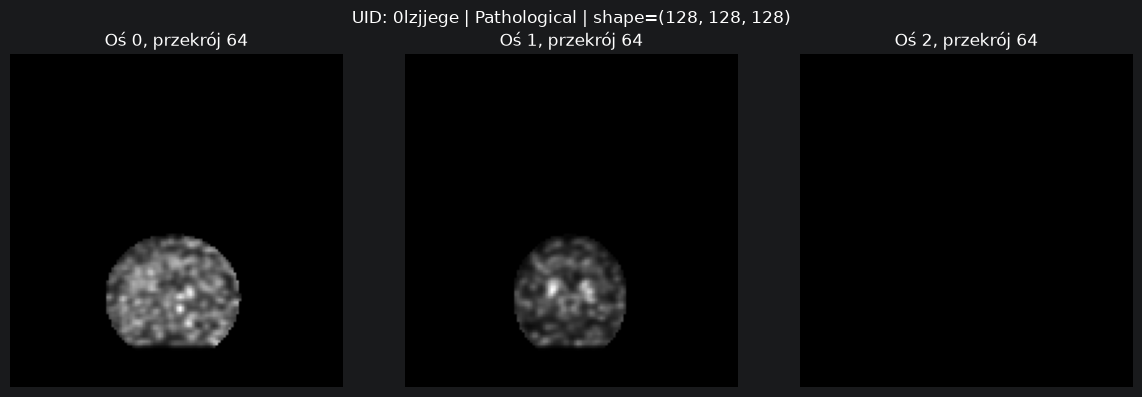

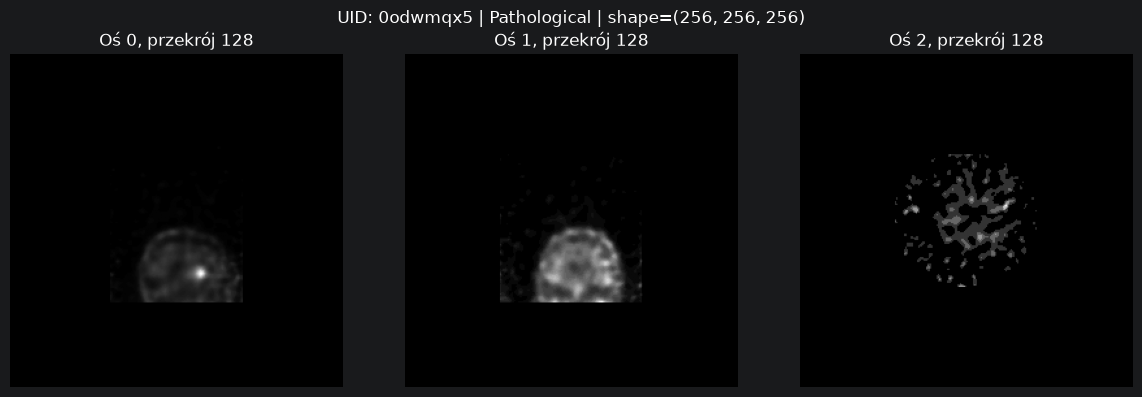

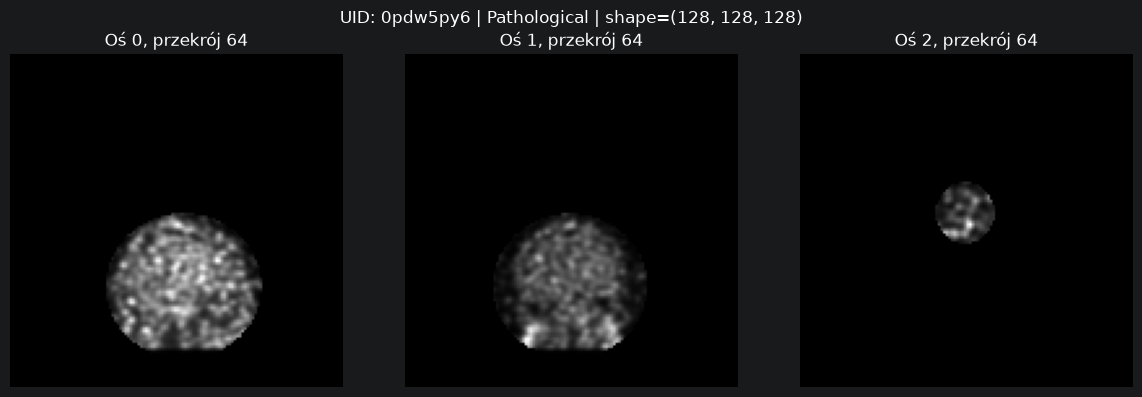

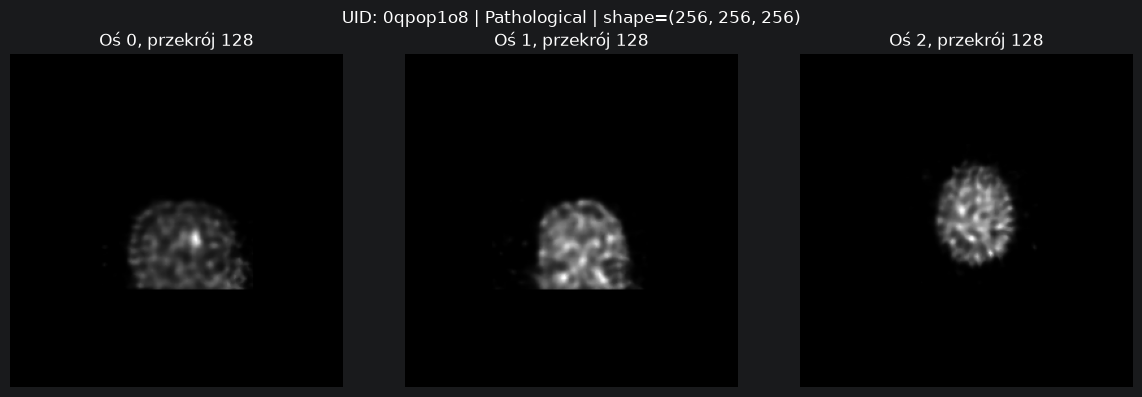

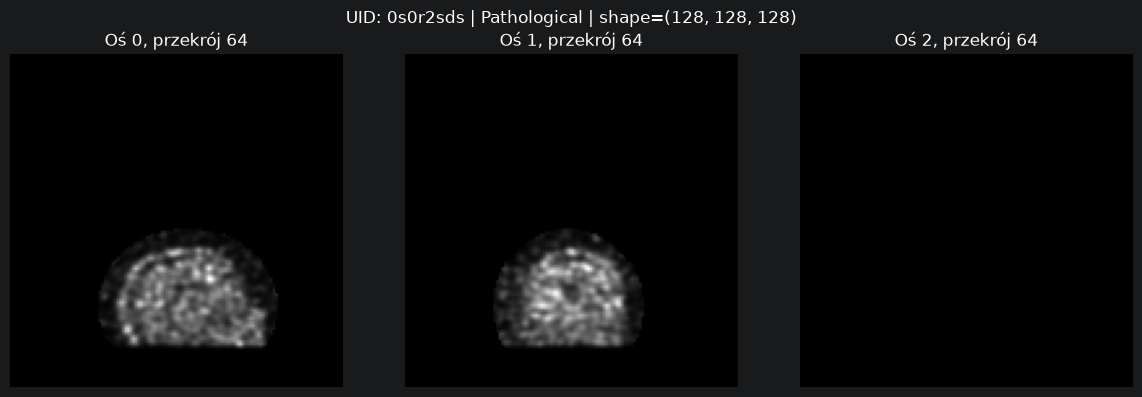

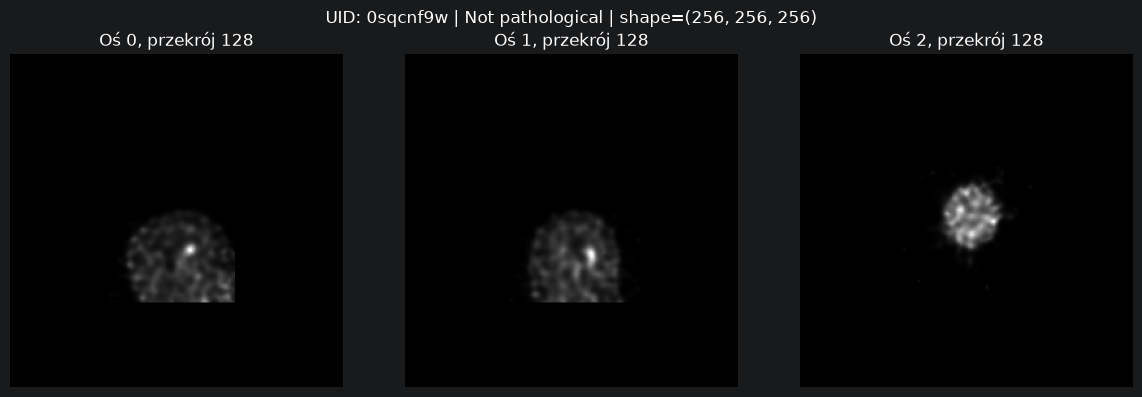

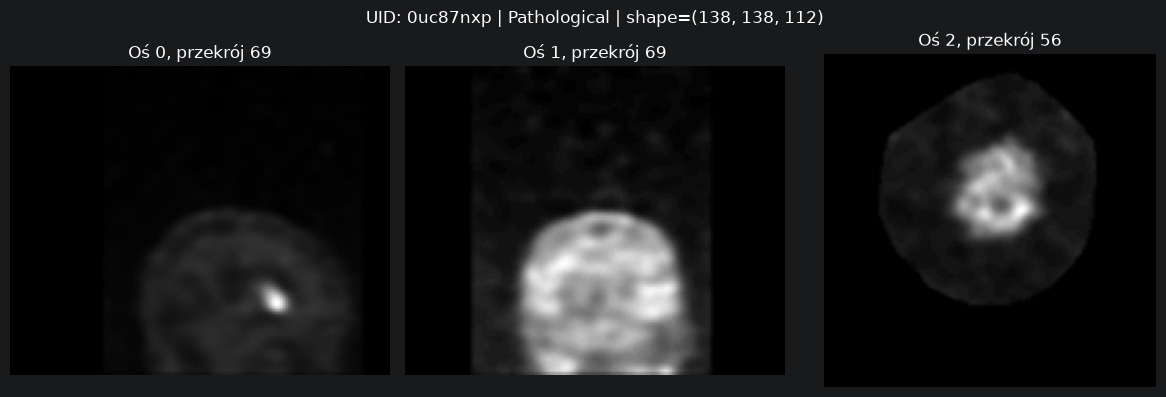

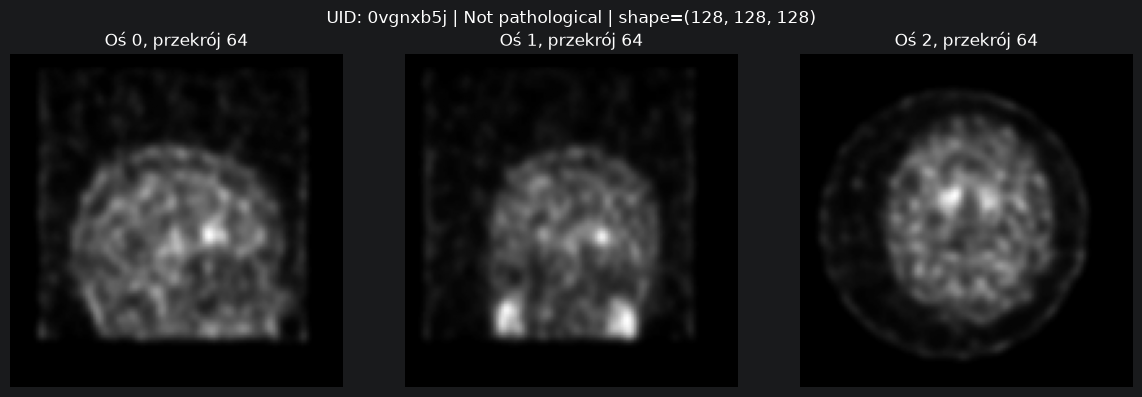

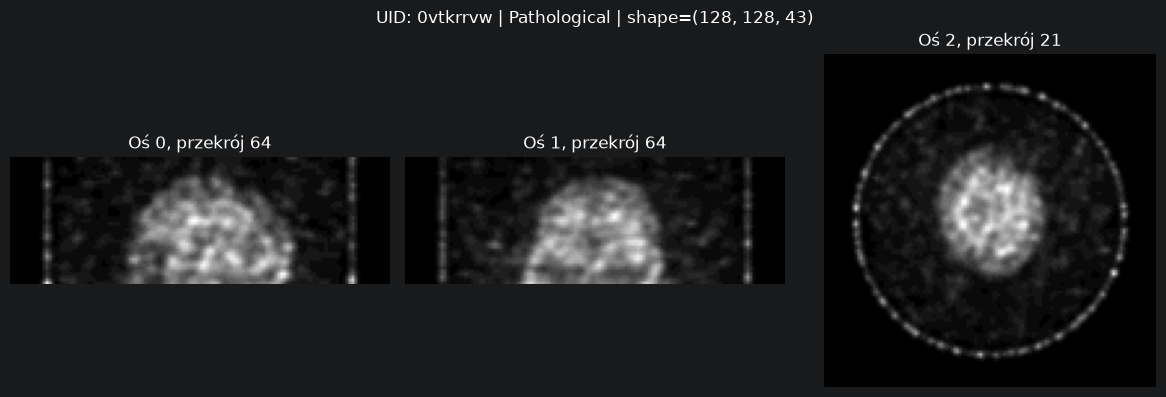

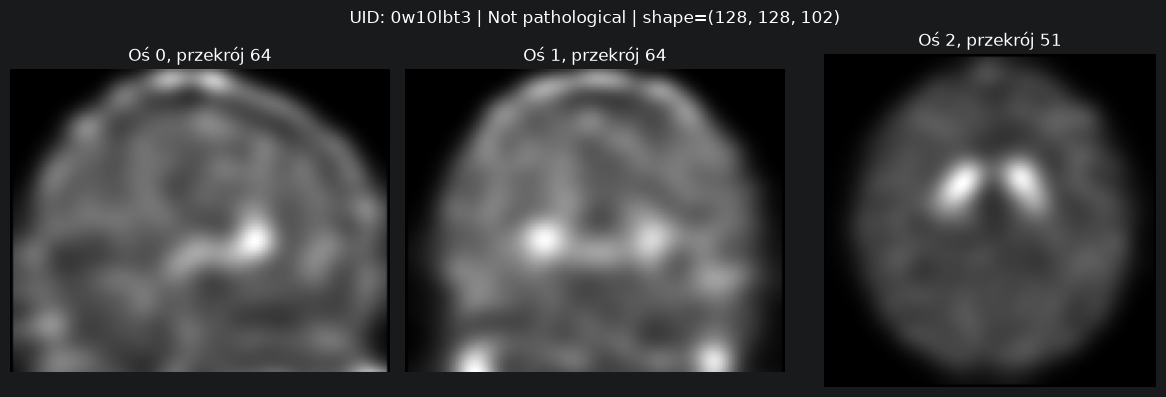

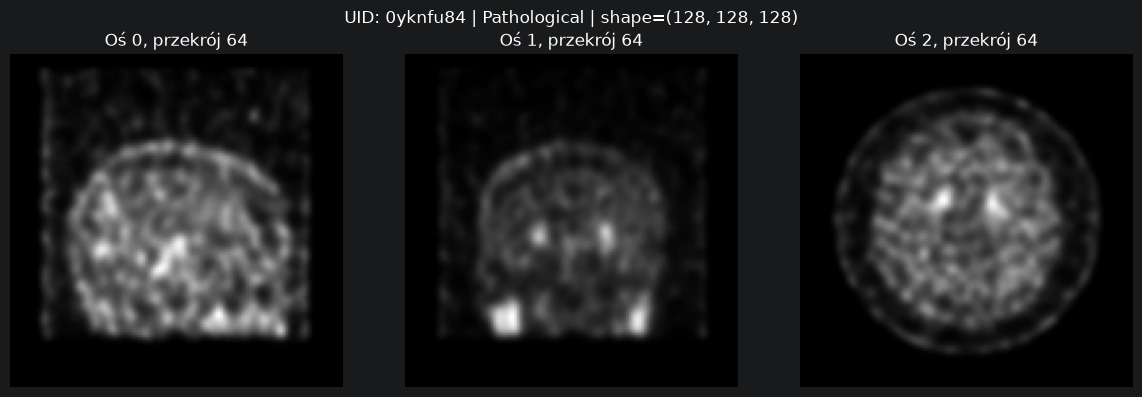

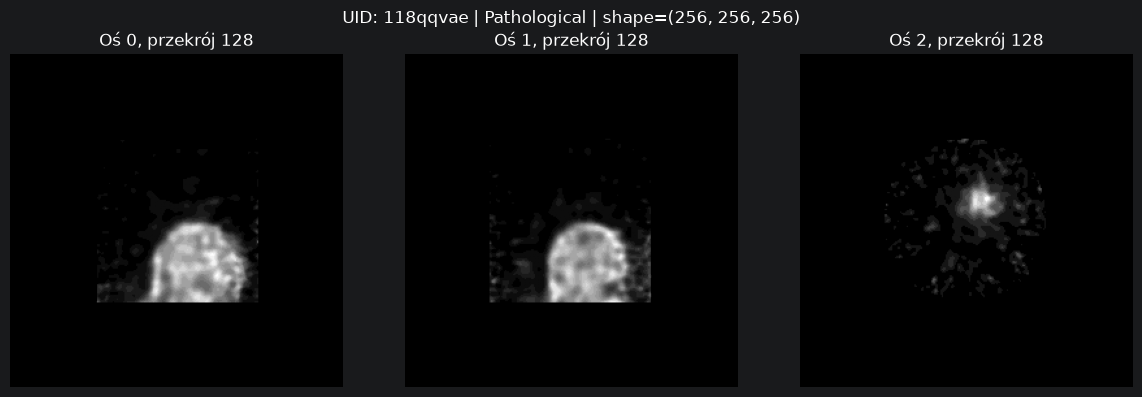

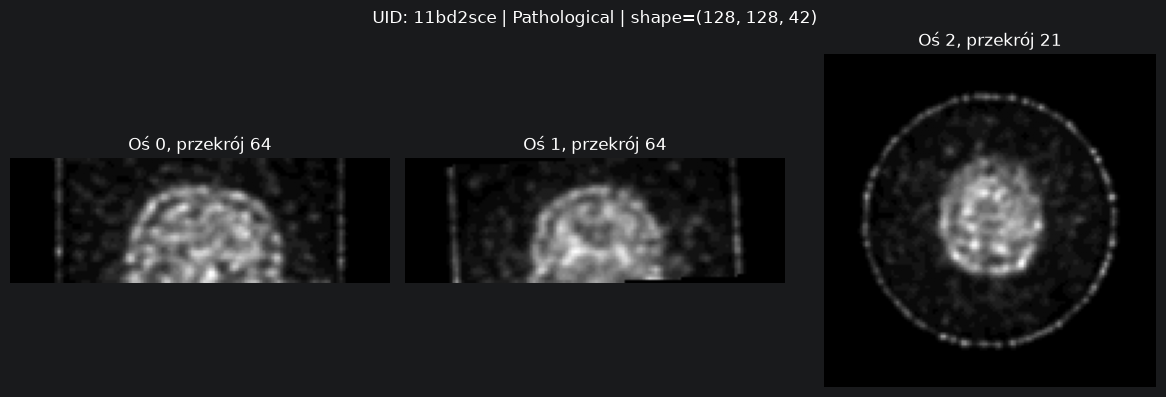

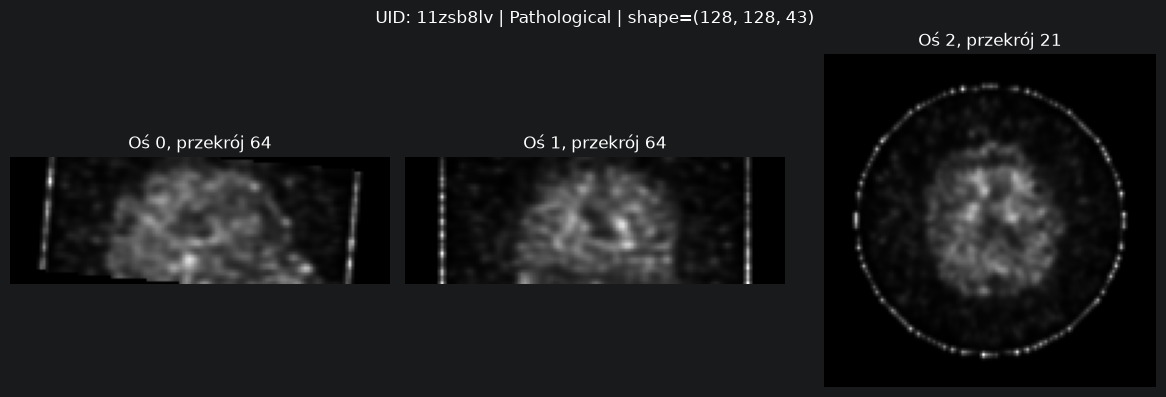

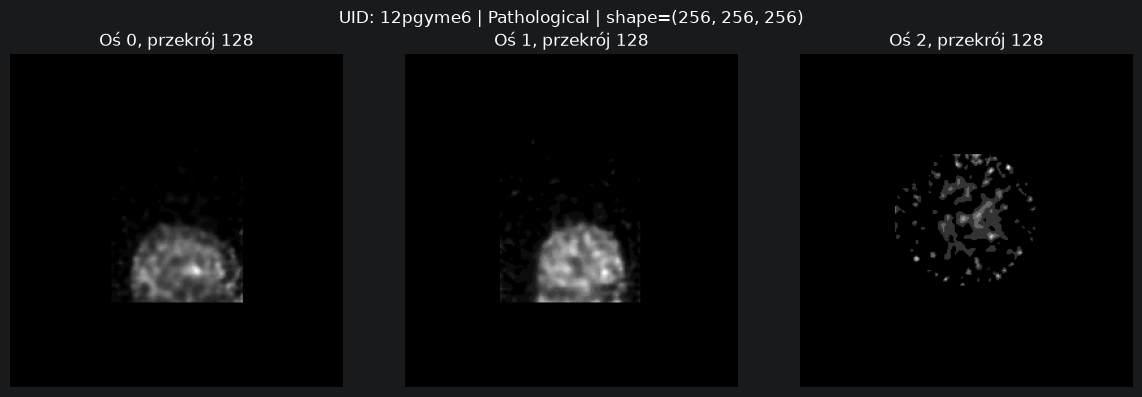

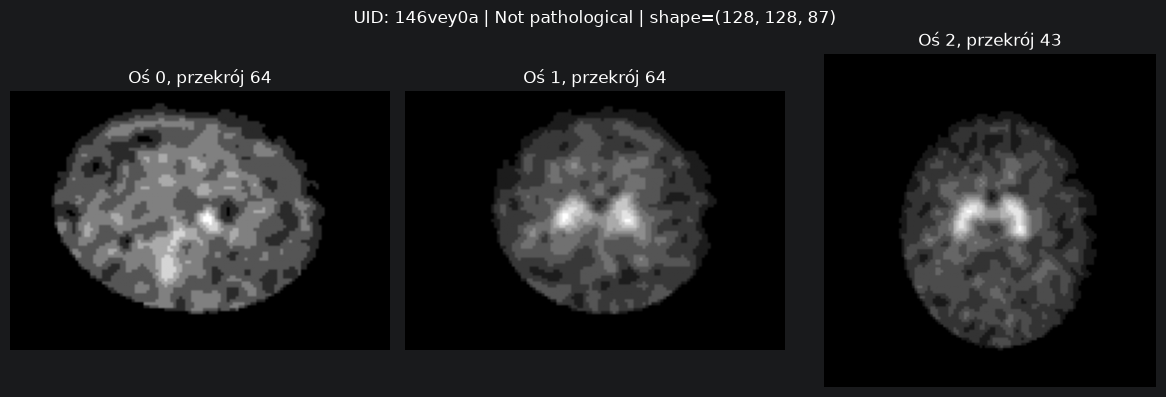

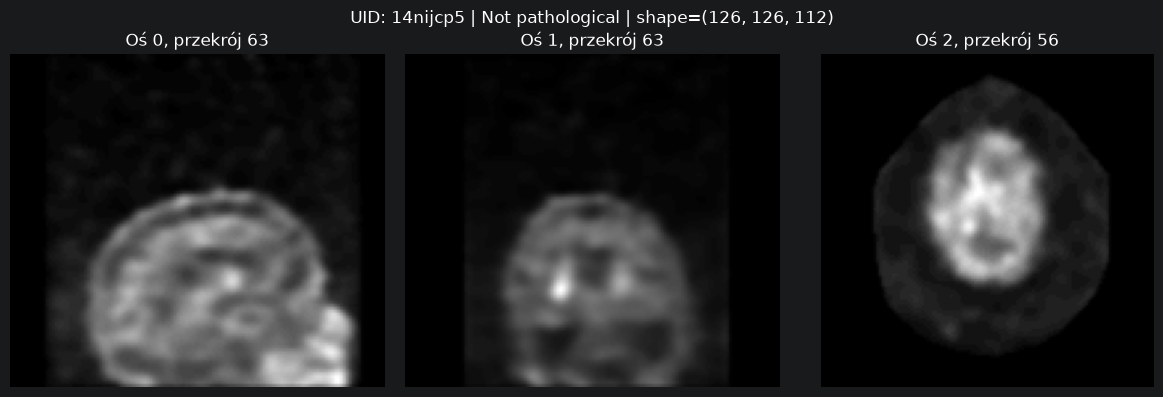

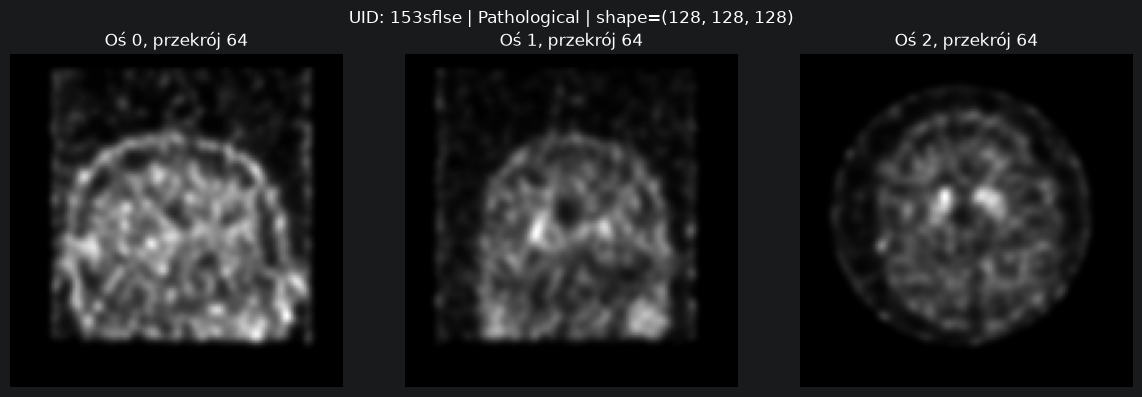

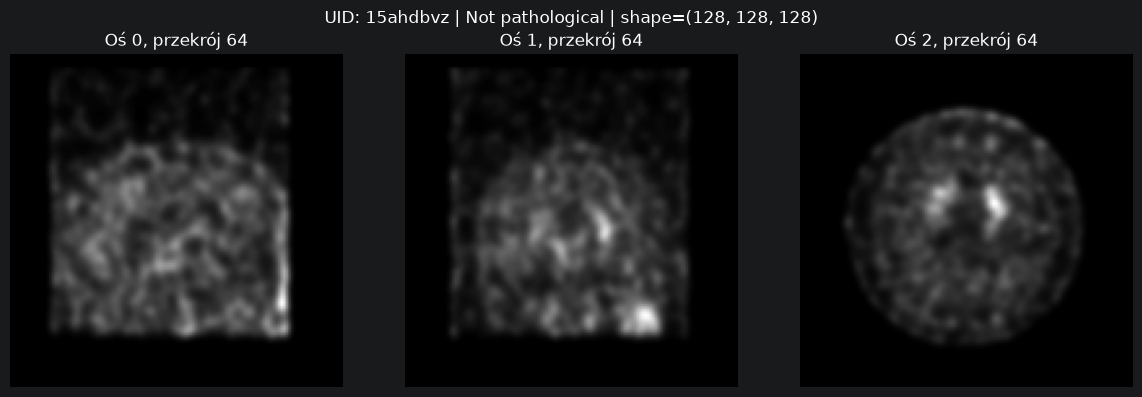

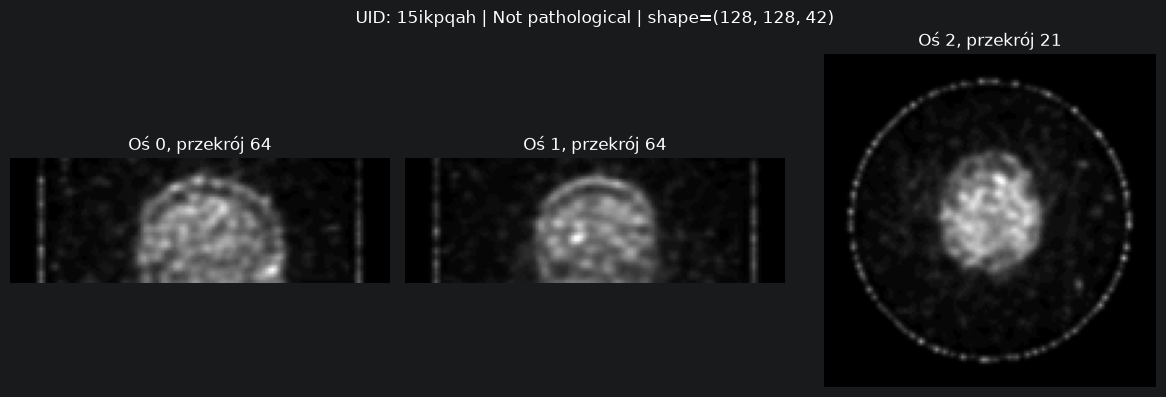

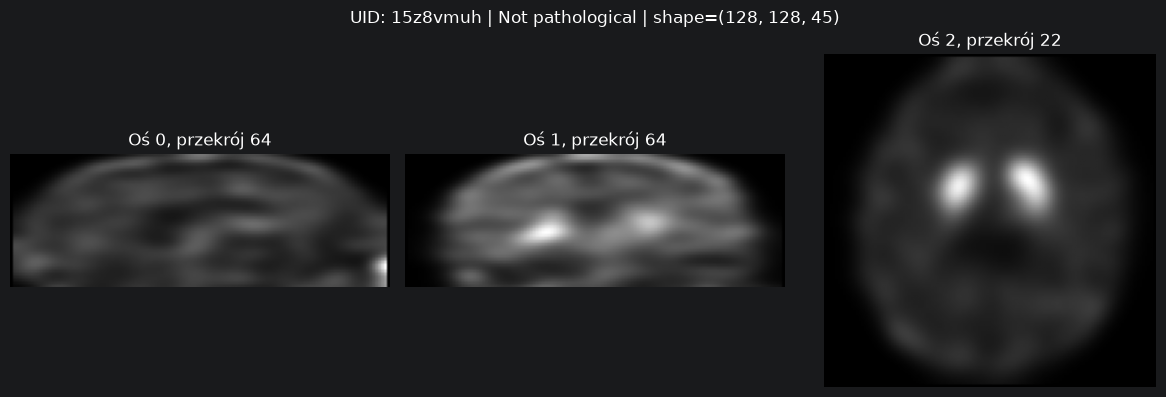

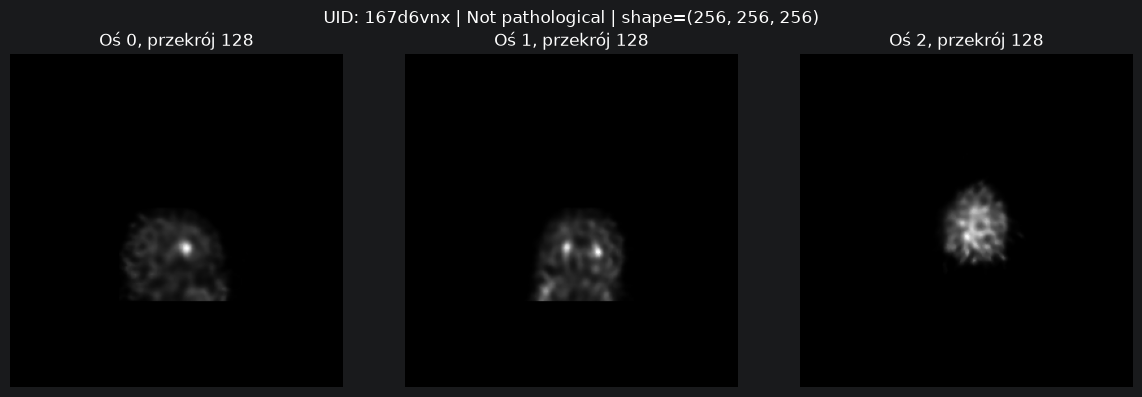

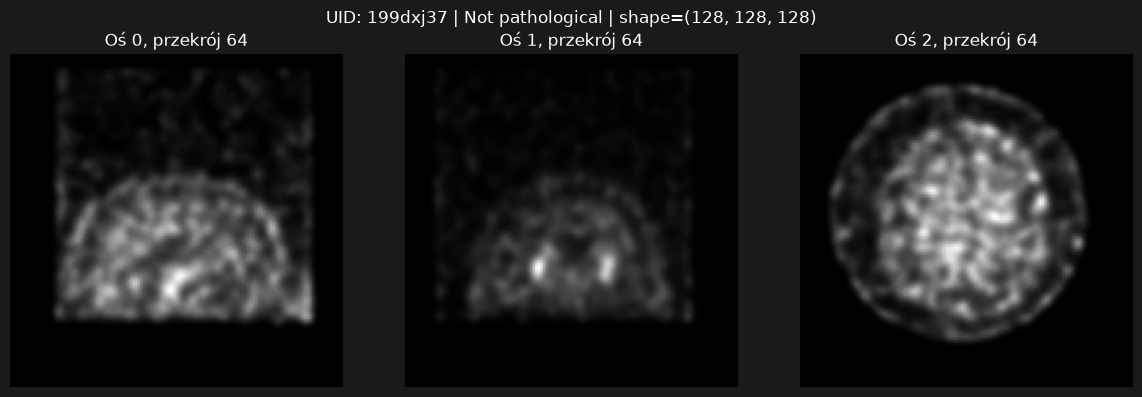

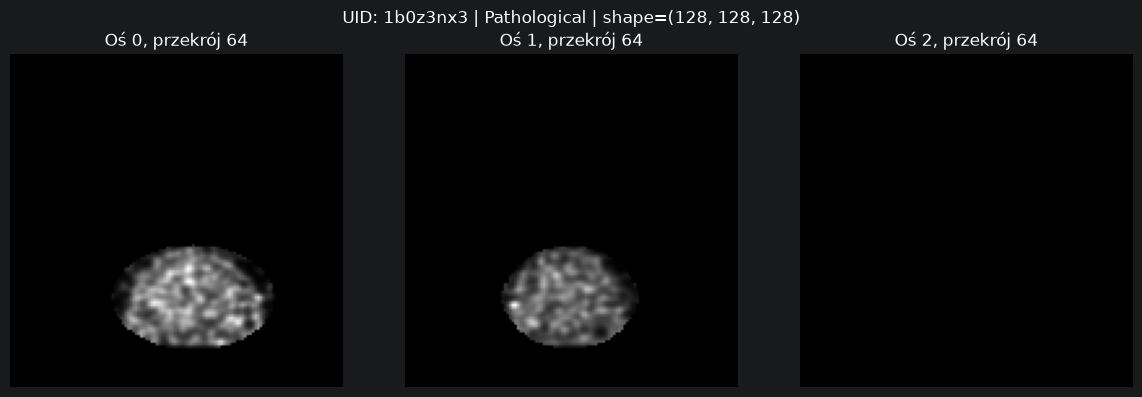

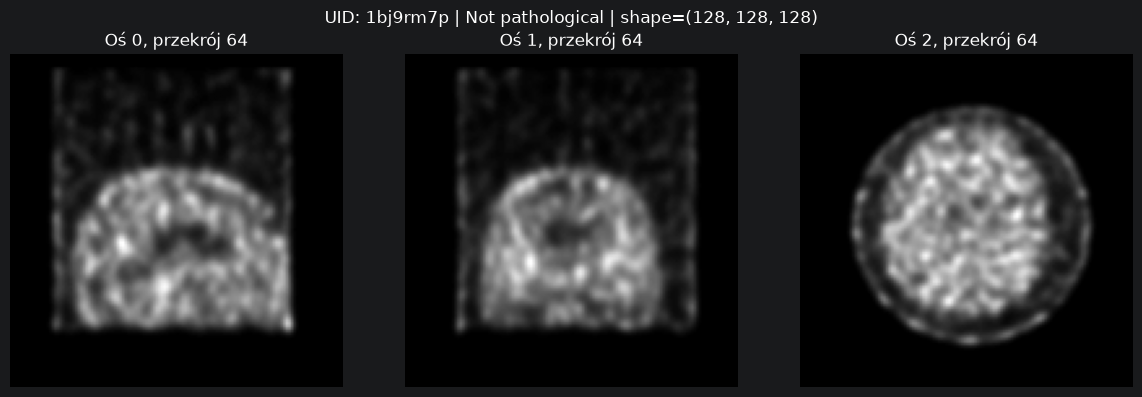

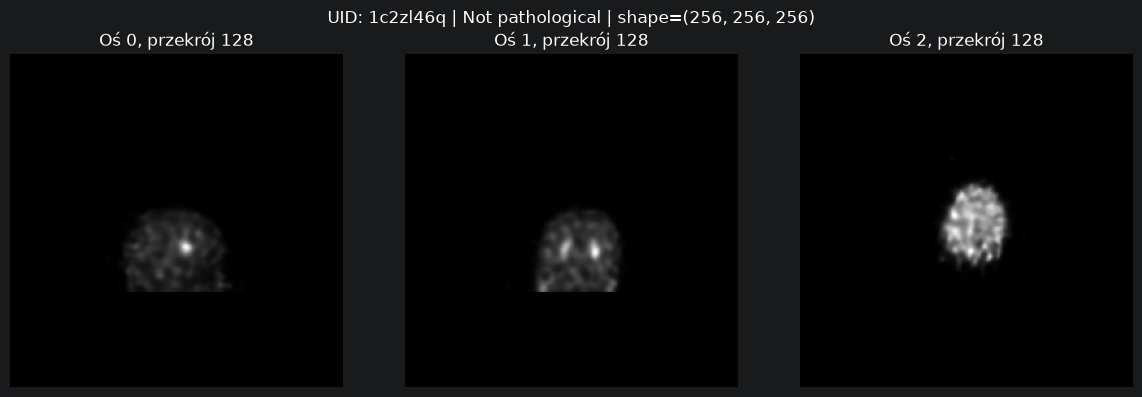

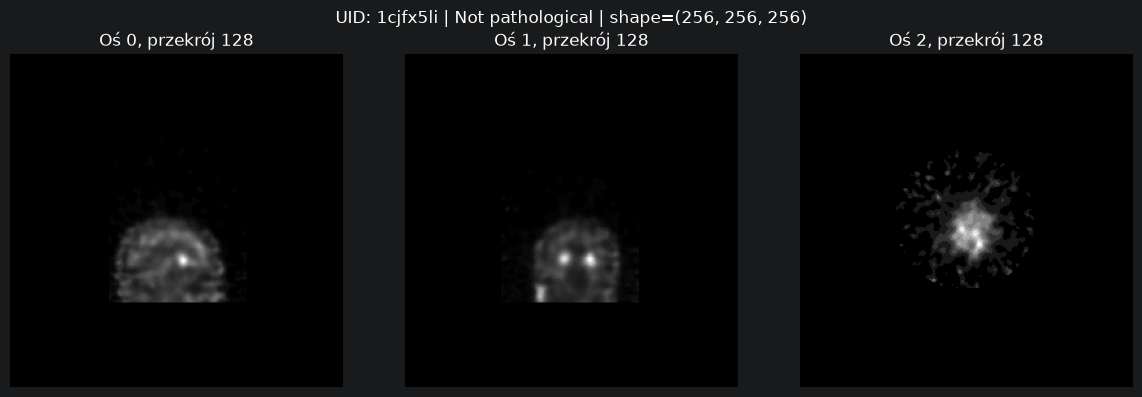

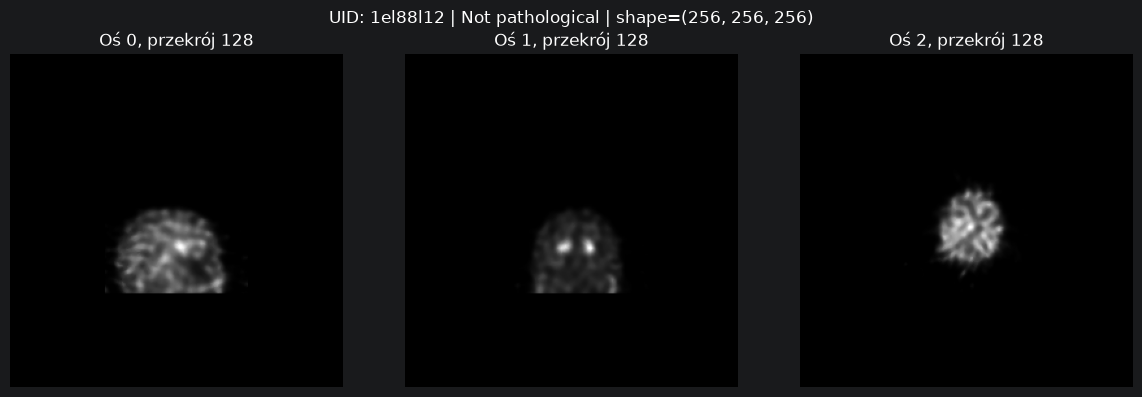

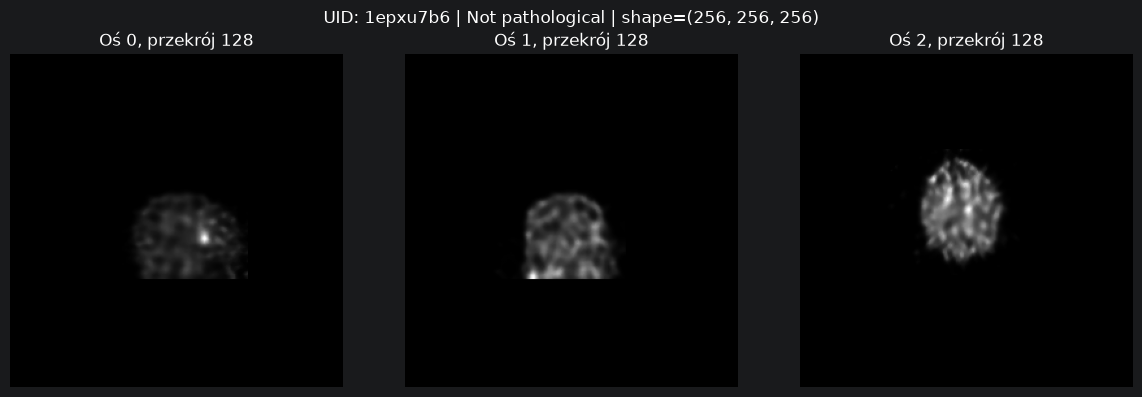

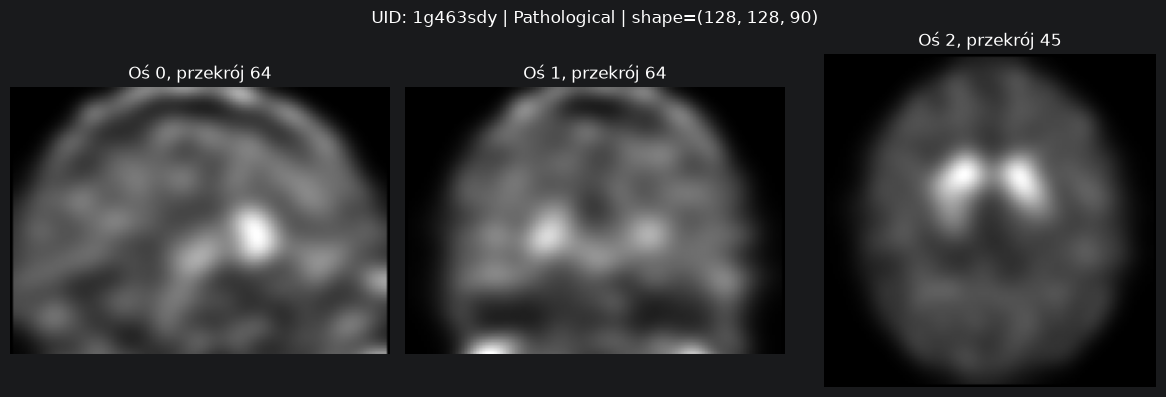

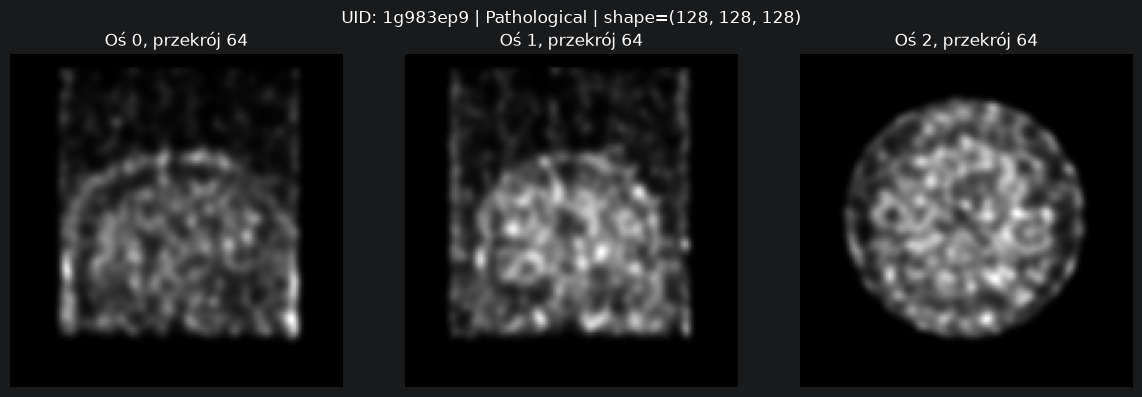

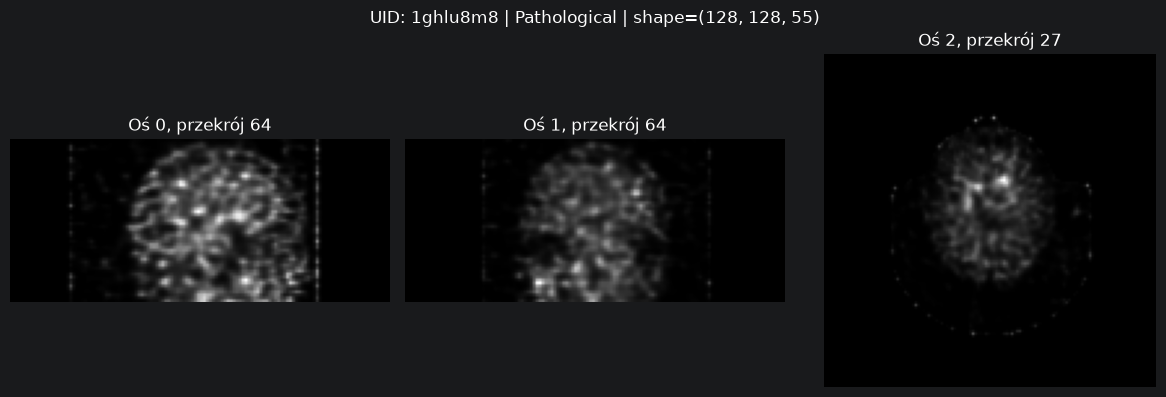

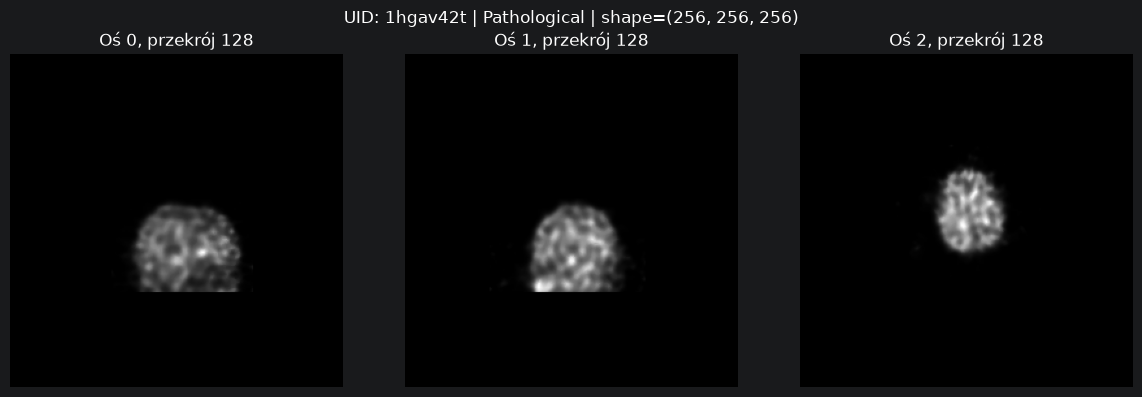

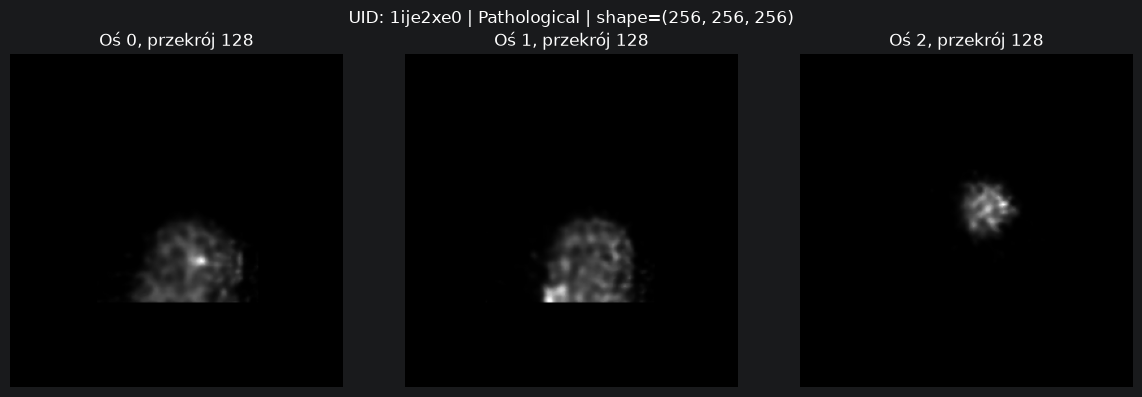

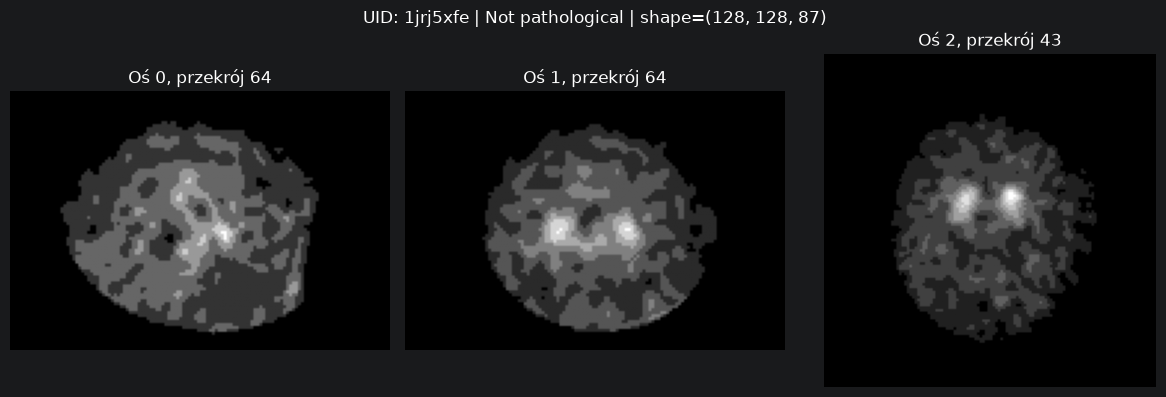

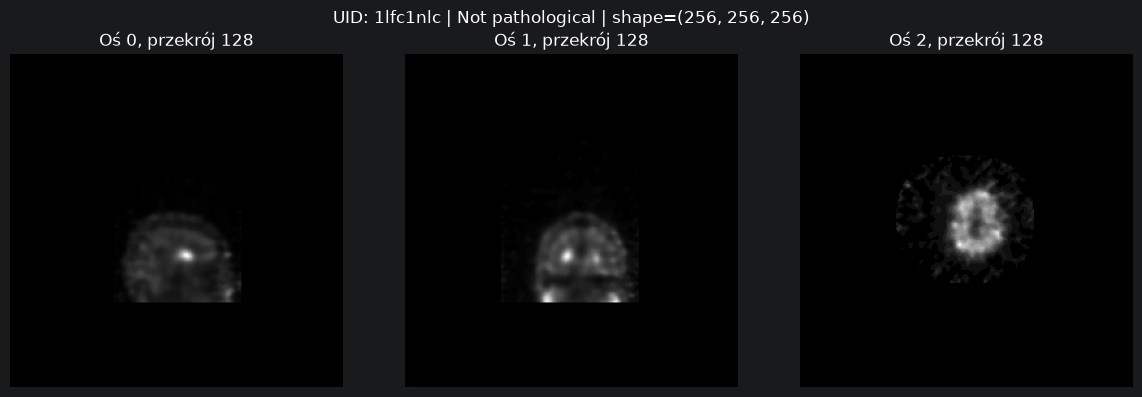

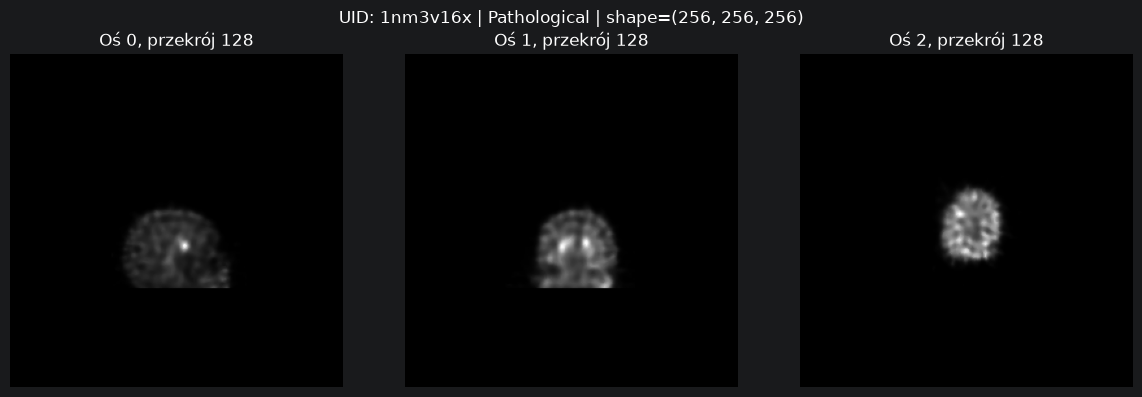

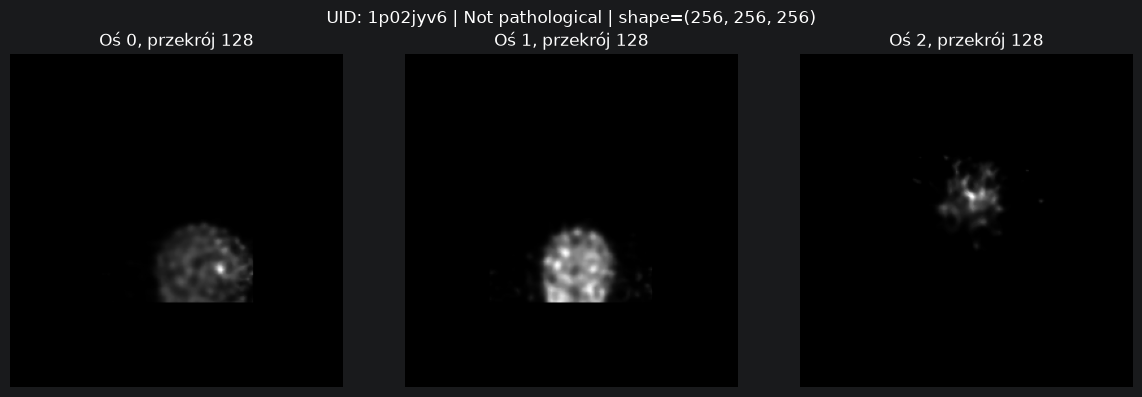

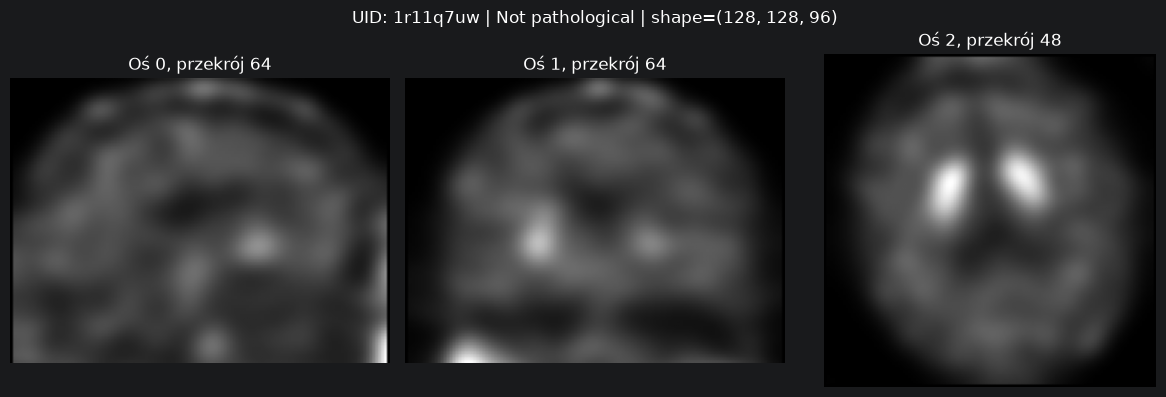

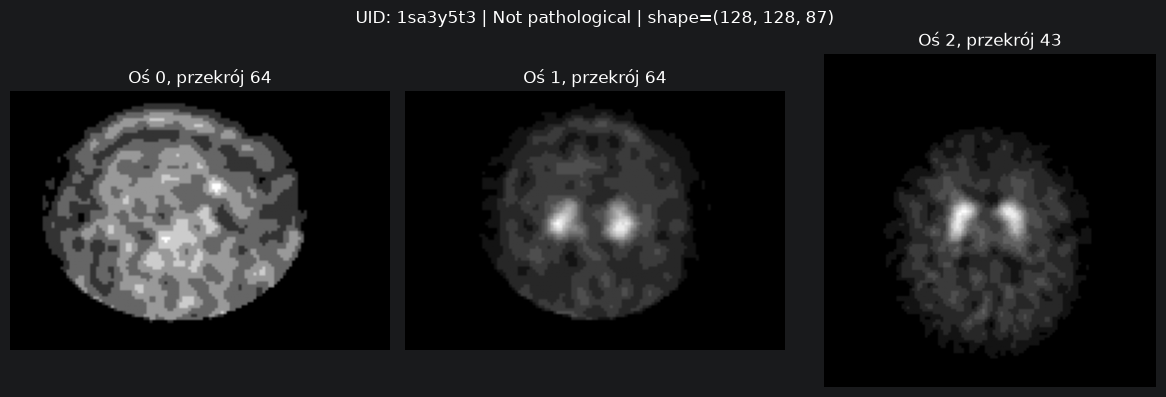

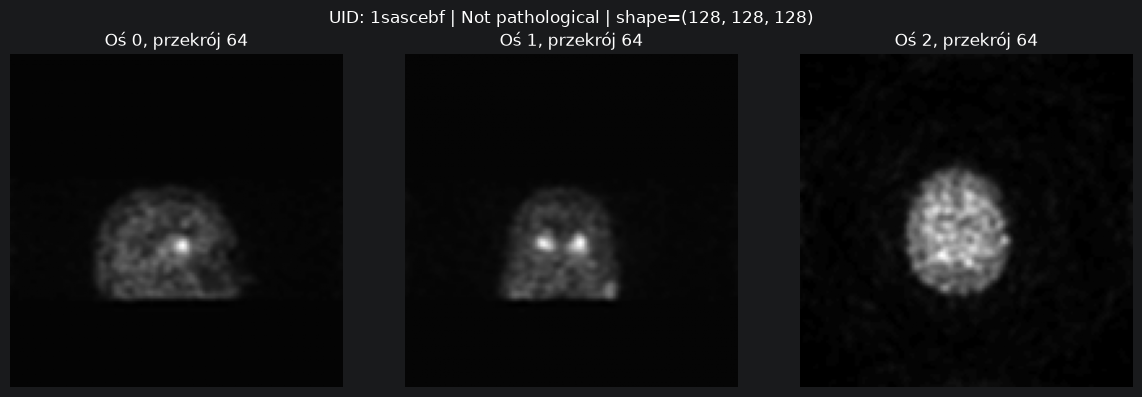

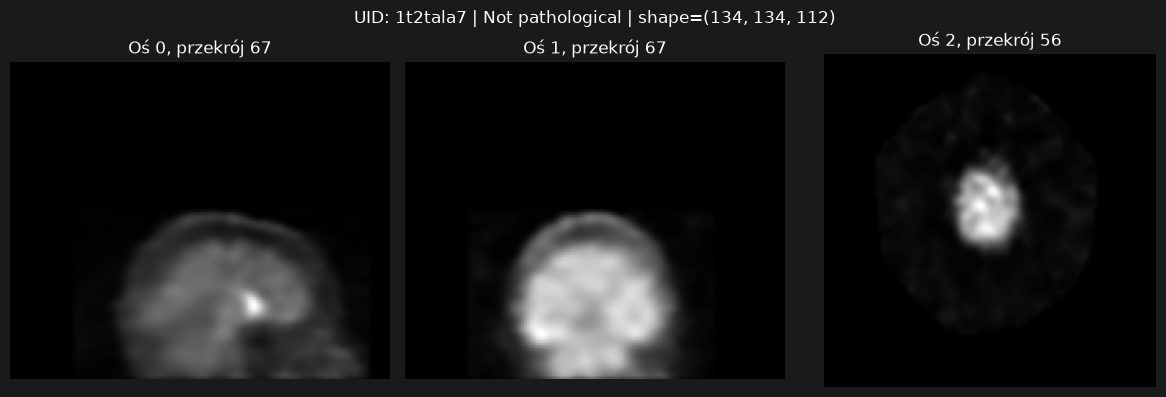

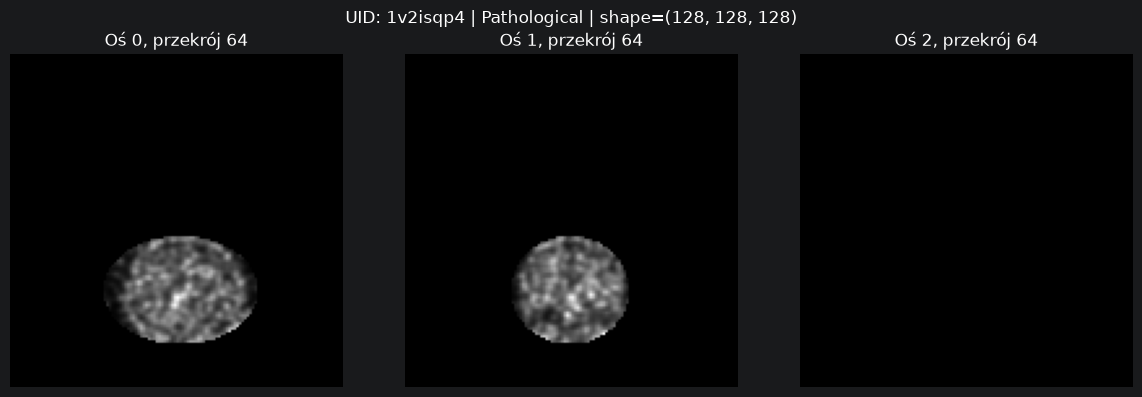

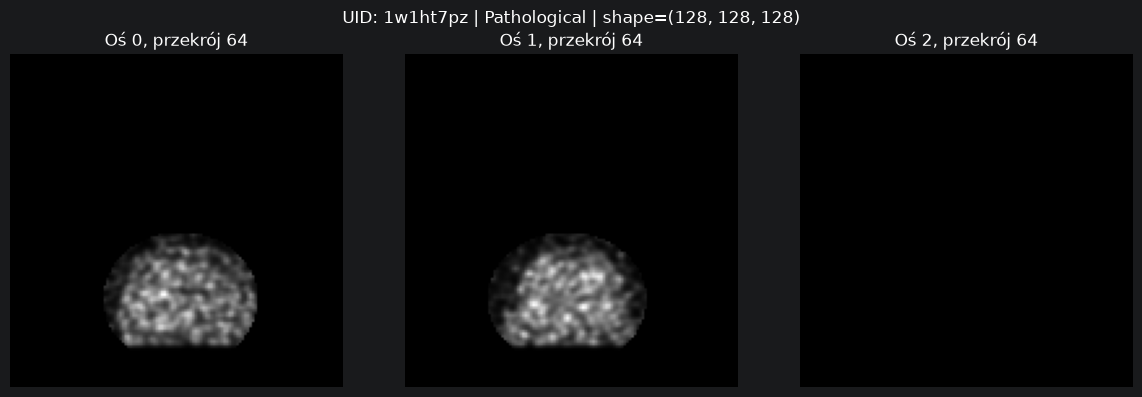

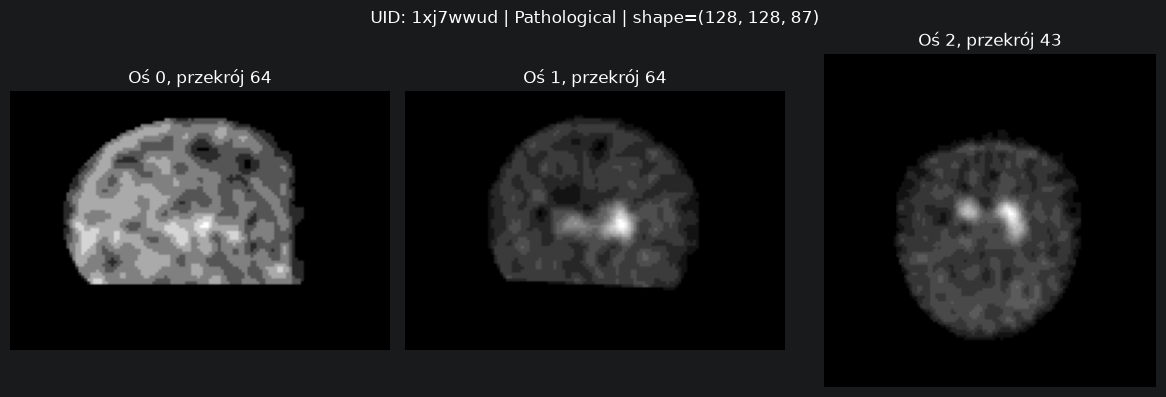

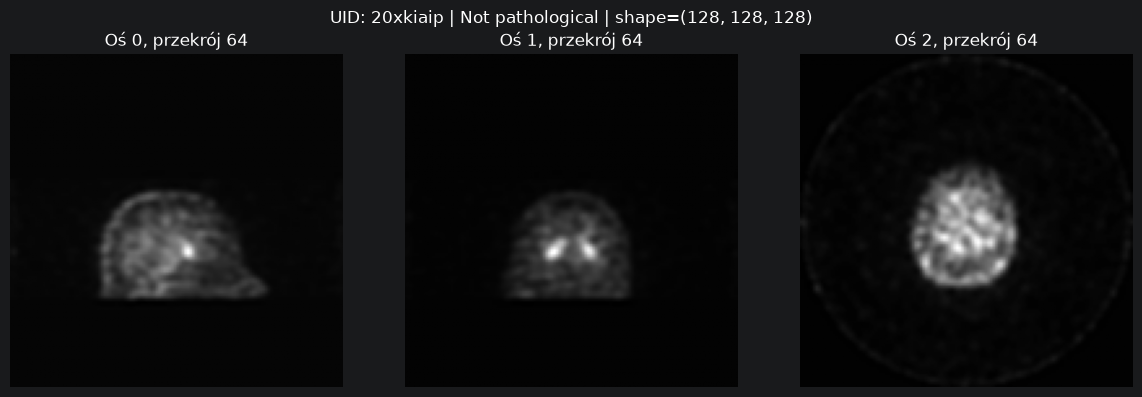

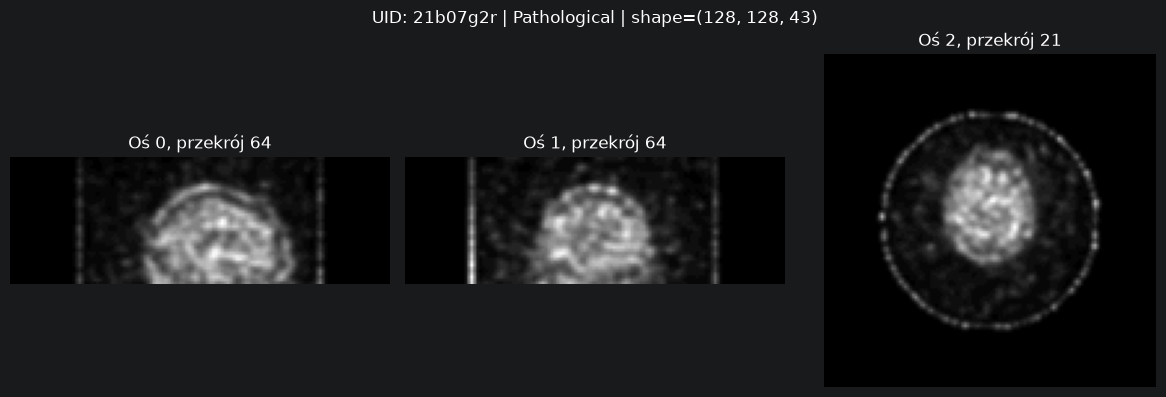

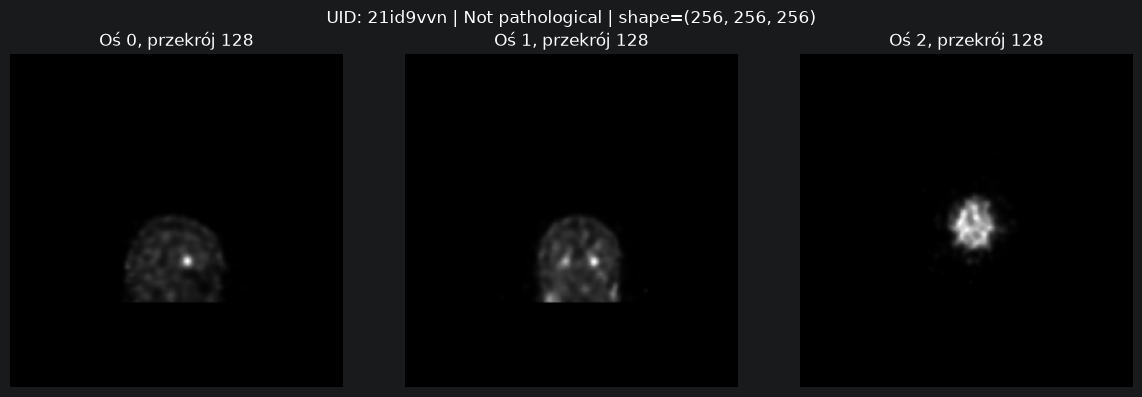

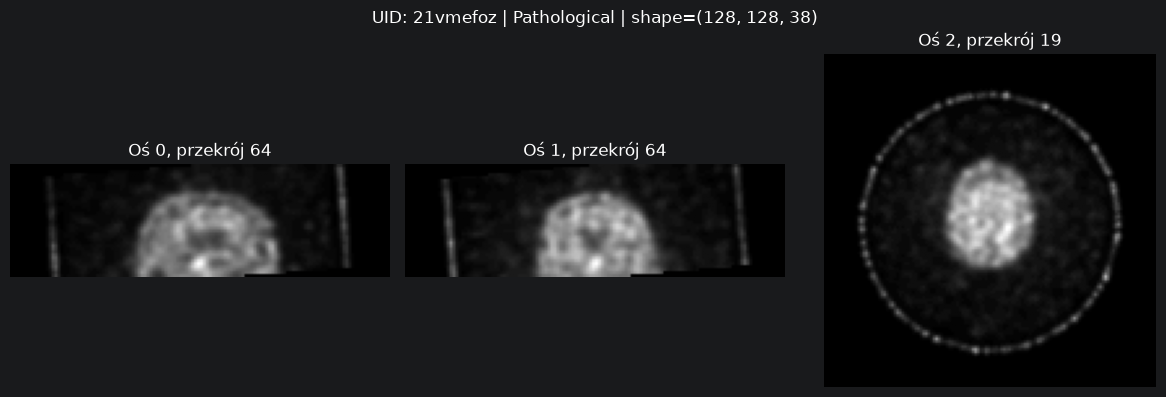

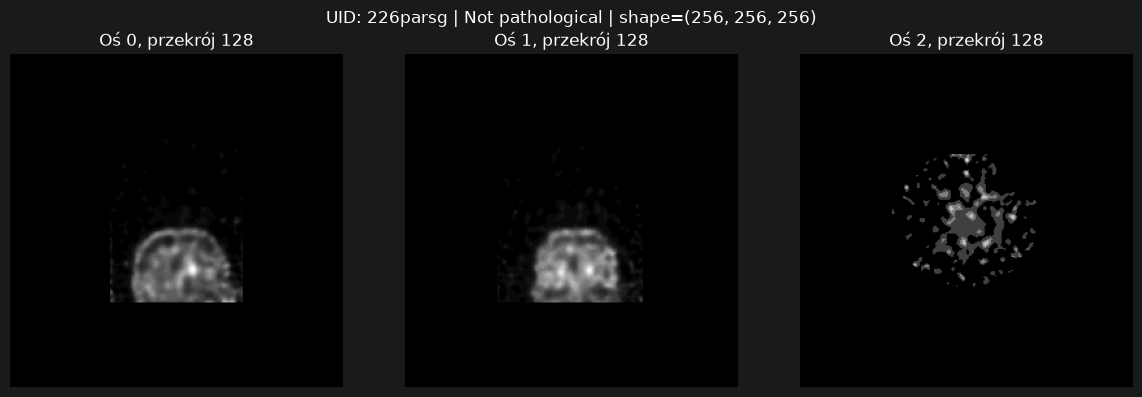

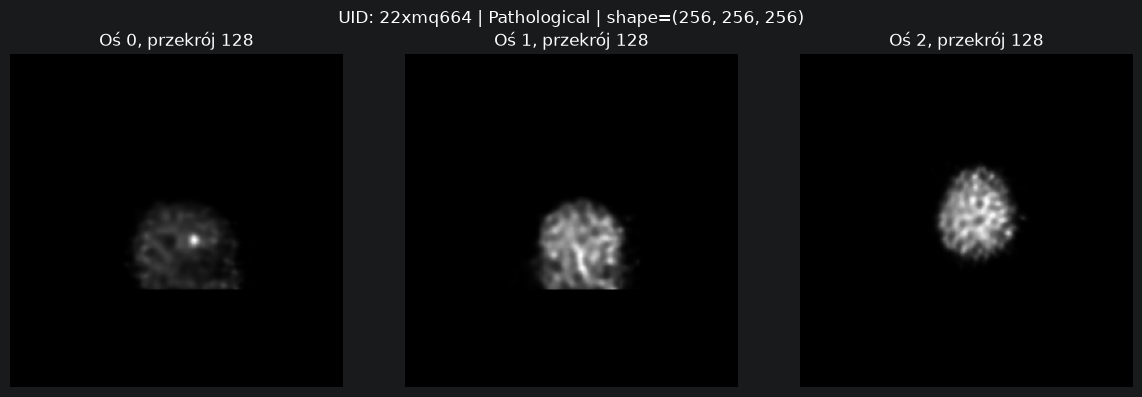

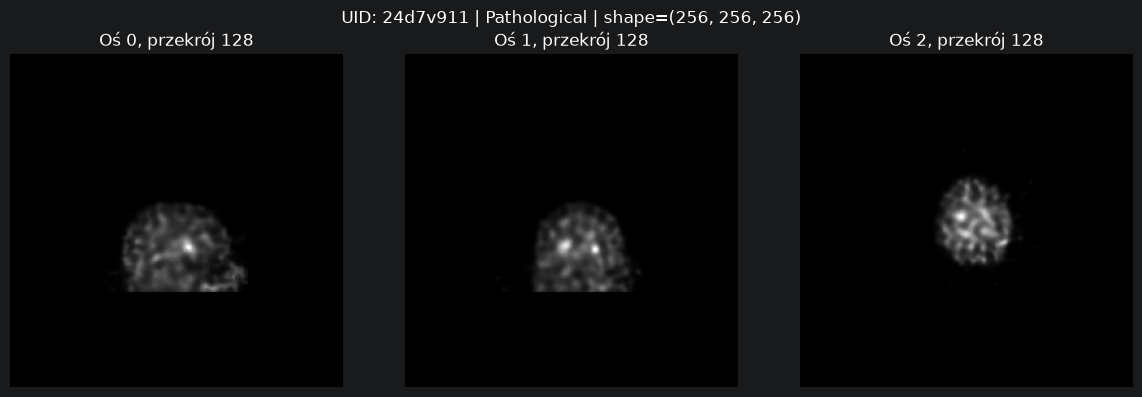

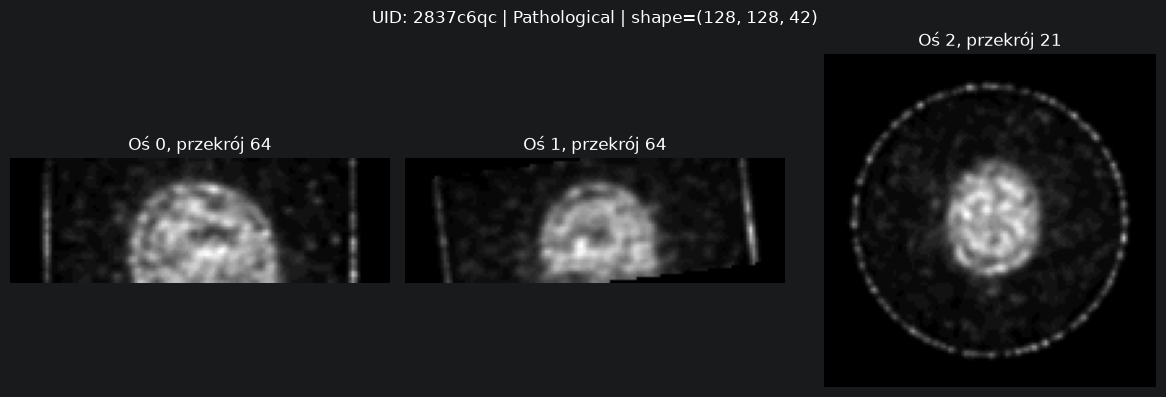

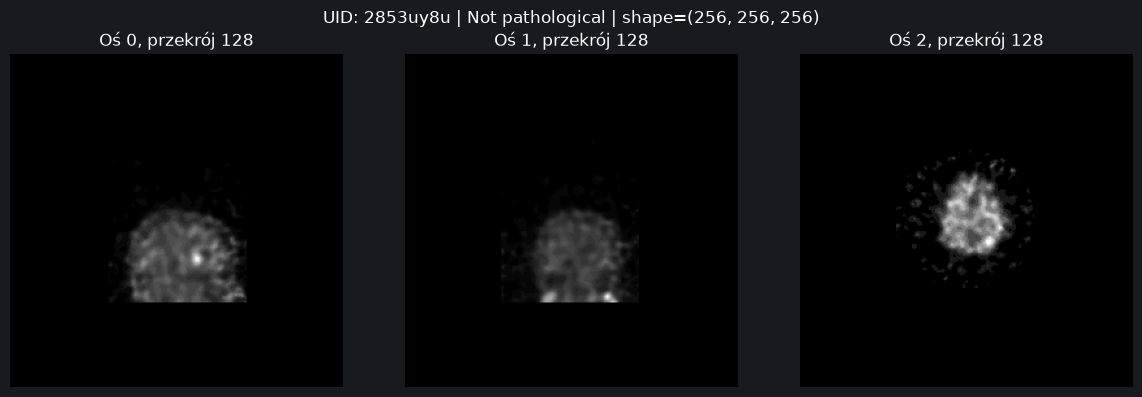

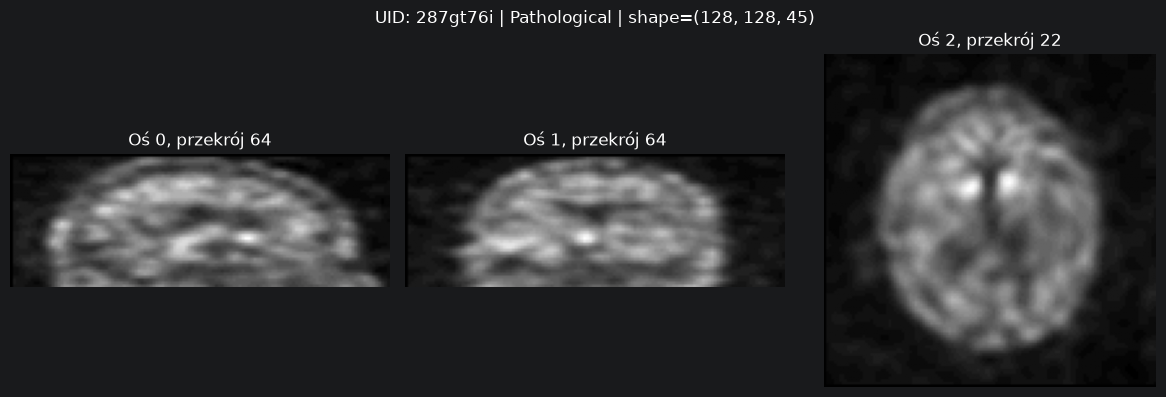

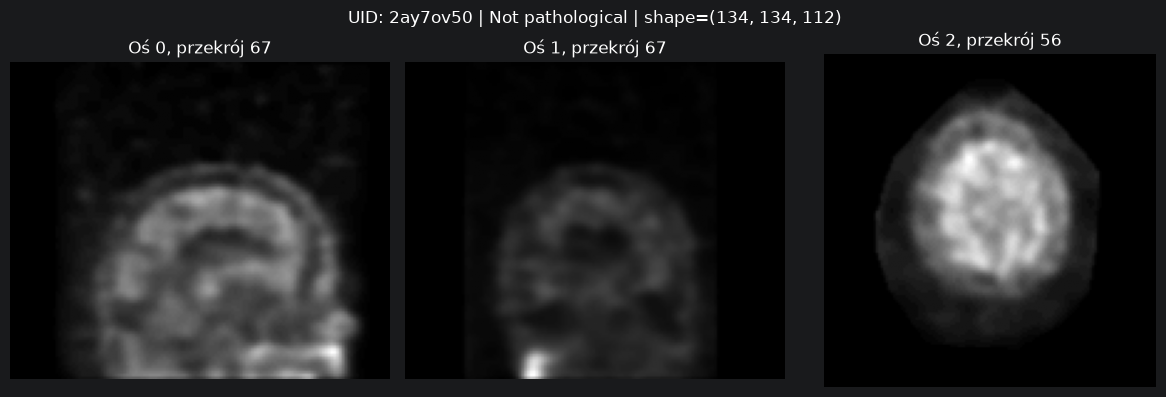

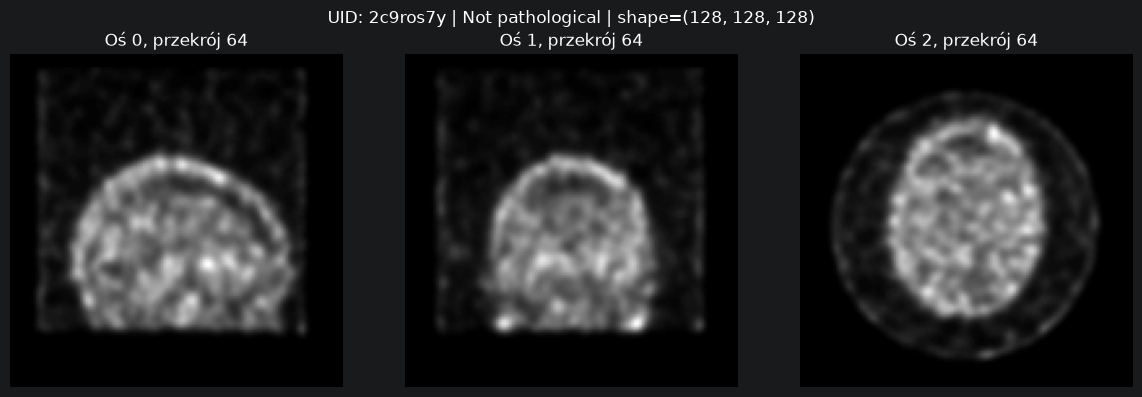

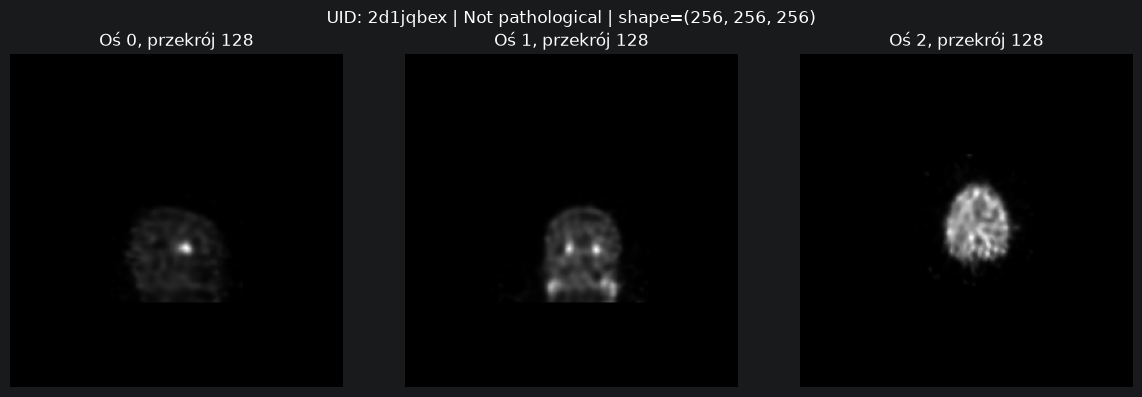

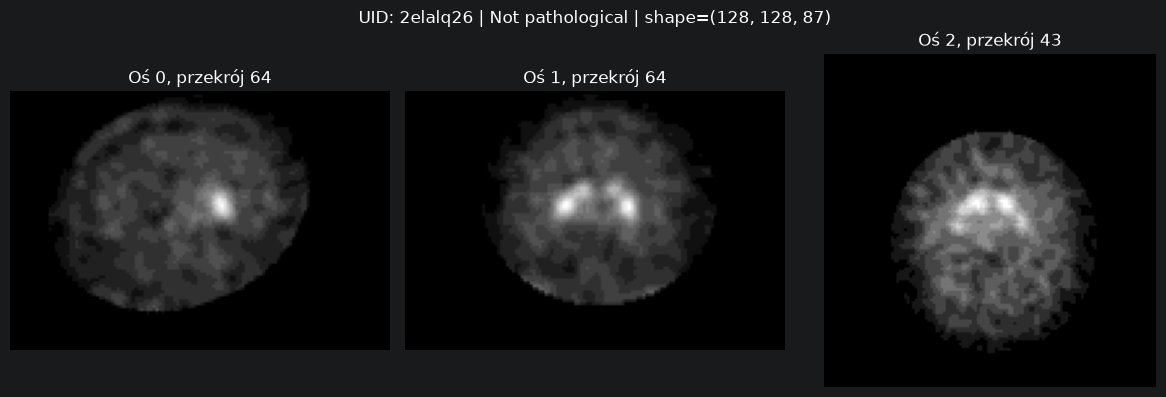

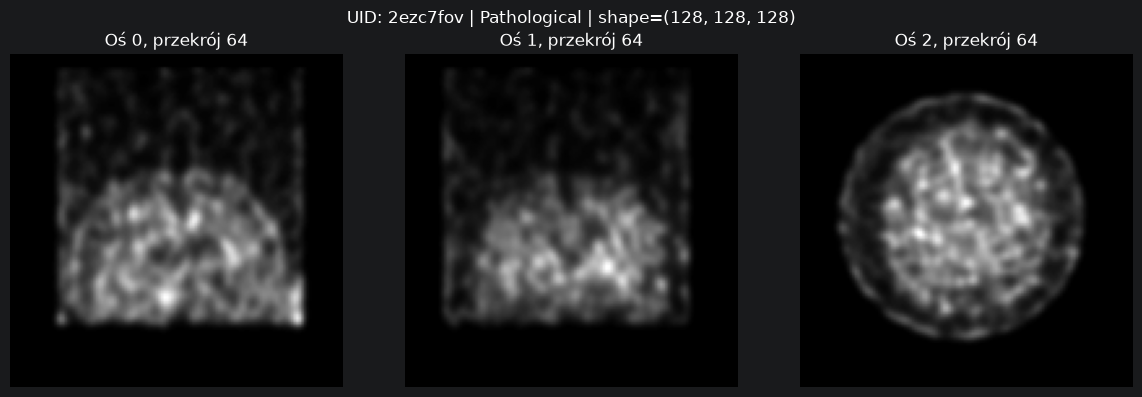

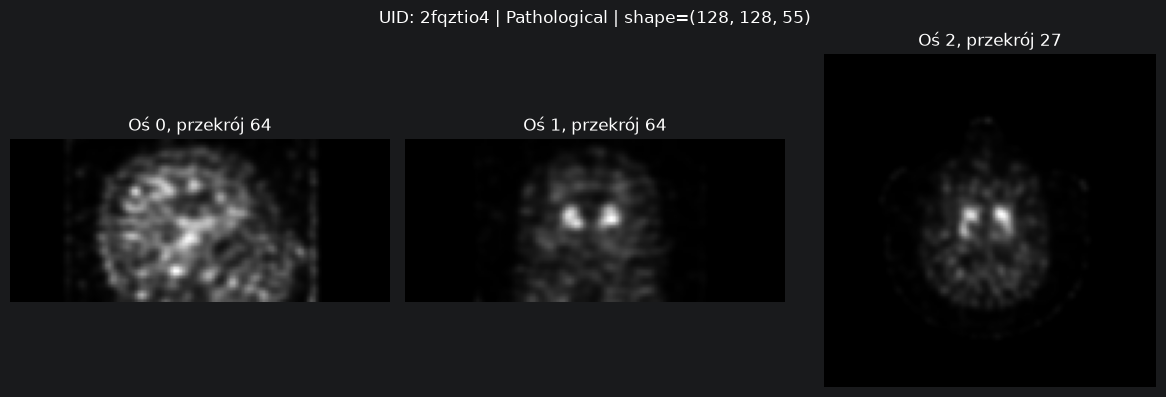

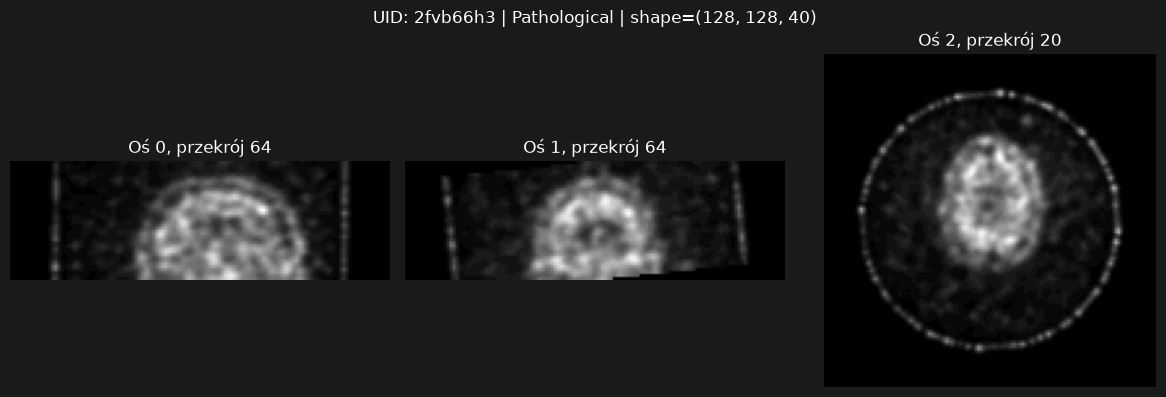

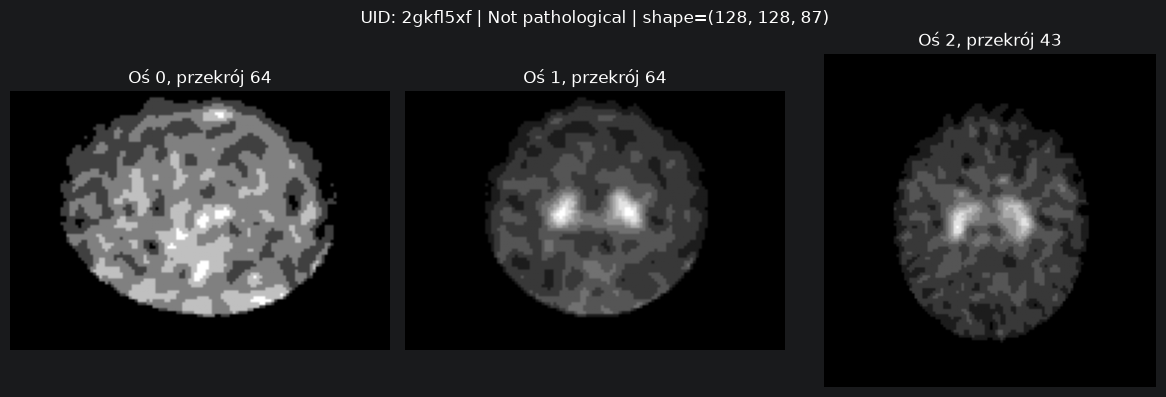

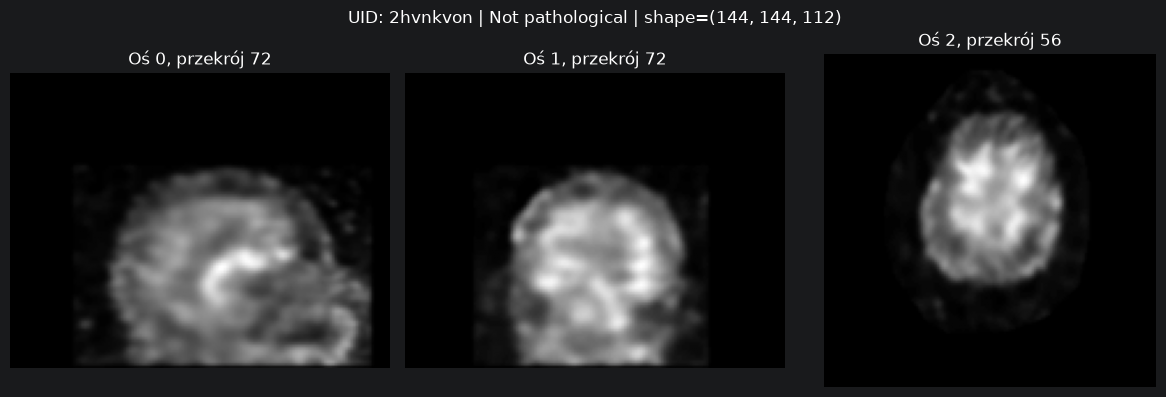

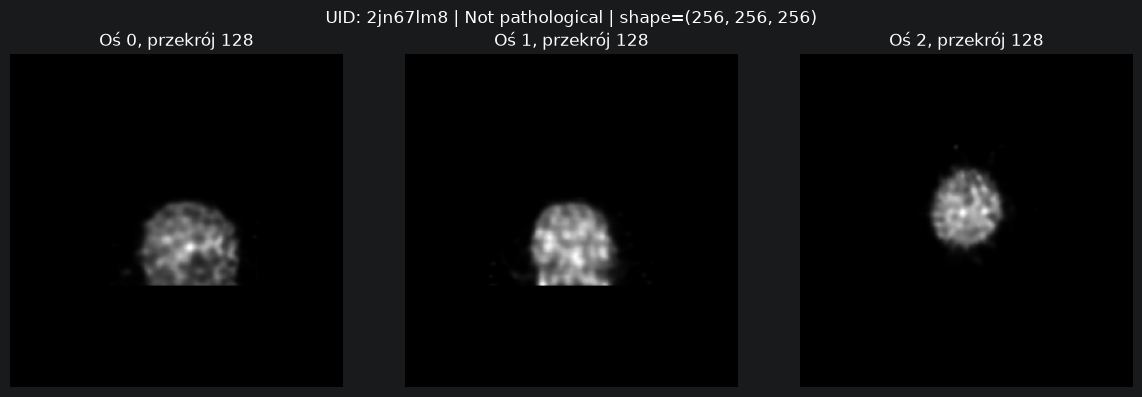

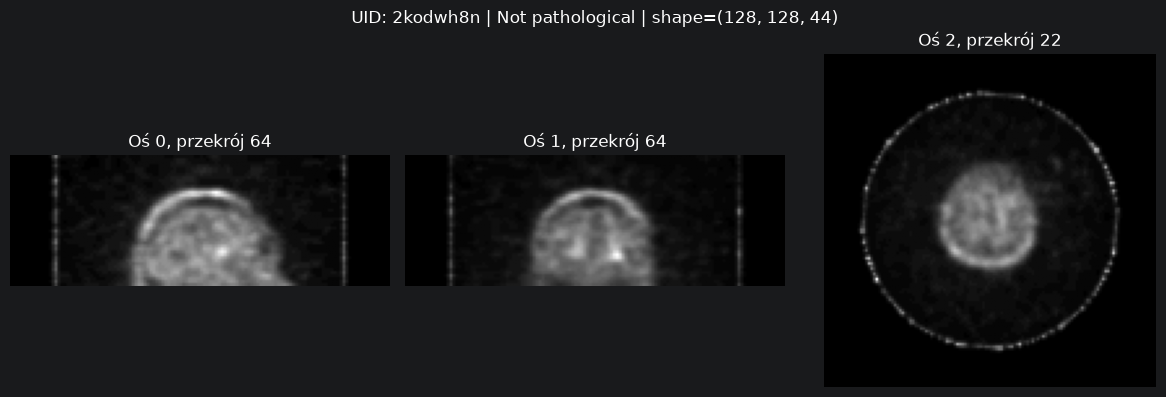

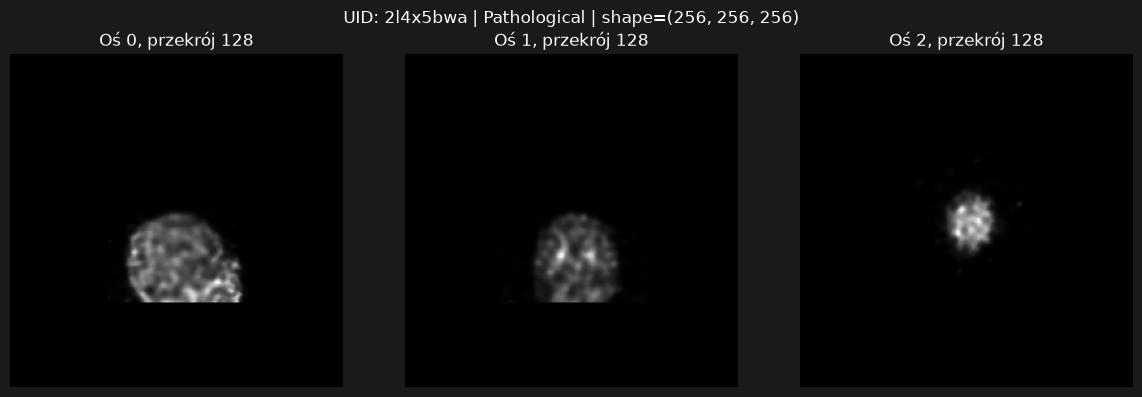

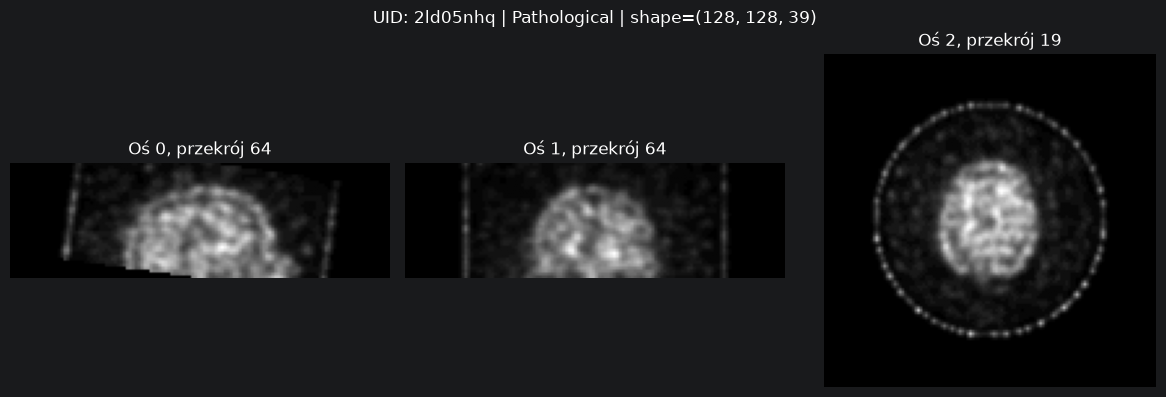

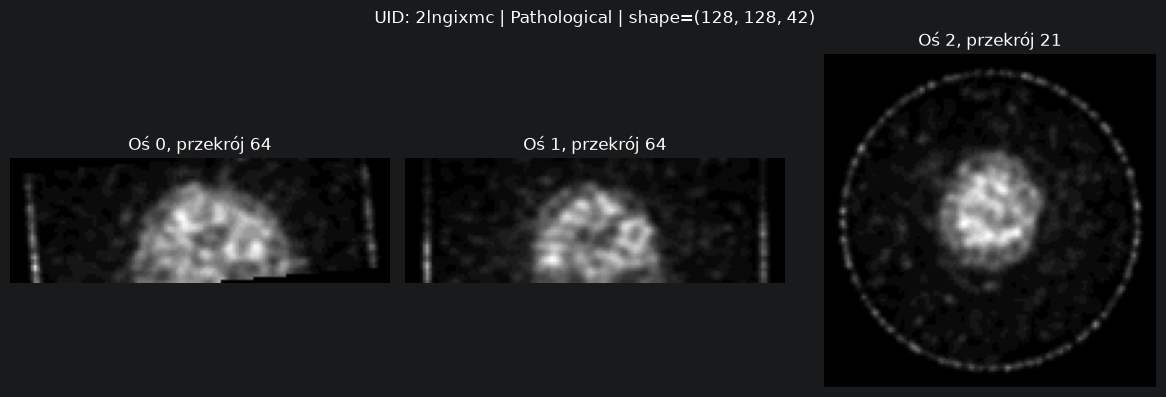

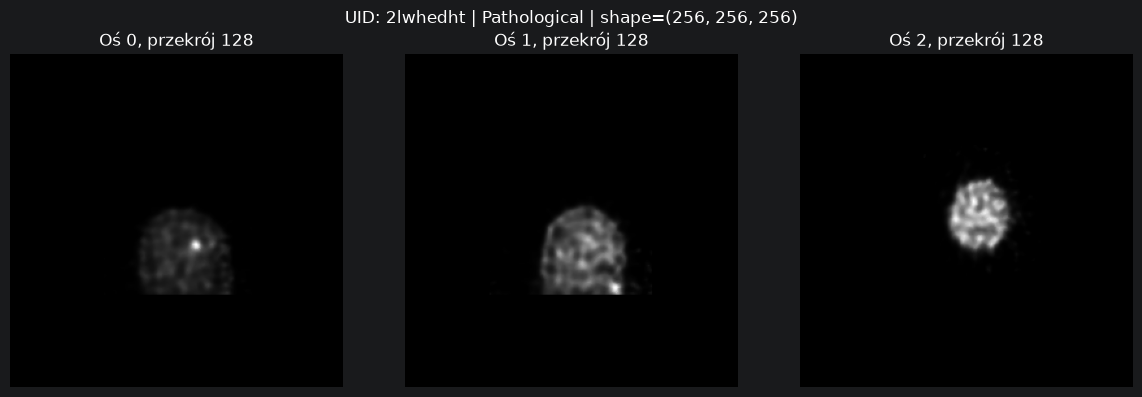

In [15]:
target_map = labels.set_index("uid")["is_pathologic"].to_dict()

for i in range(100):
    file = files[i]

    uid = file.stem.replace(".nii", "")
    target = target_map[uid]

    diagnosis = "Pathological" if target == 1 else "Not pathological"

    volume = nib.load(file).get_fdata()

    x = volume.shape[0] // 2
    y = volume.shape[1] // 2
    z = volume.shape[2] // 2

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].imshow(volume[x, :, :].T, cmap="gray", origin="lower")
    ax[1].imshow(volume[:, y, :].T, cmap="gray", origin="lower")
    ax[2].imshow(volume[:, :, z].T, cmap="gray", origin="lower")

    ax[0].set_title(f"Oś 0, przekrój {x}")
    ax[1].set_title(f"Oś 1, przekrój {y}")
    ax[2].set_title(f"Oś 2, przekrój {z}")

    for a in ax:
        a.axis("off")

    fig.suptitle(
        f"UID: {uid} | {diagnosis} | shape={volume.shape}"
    )

    plt.tight_layout()
    plt.show()